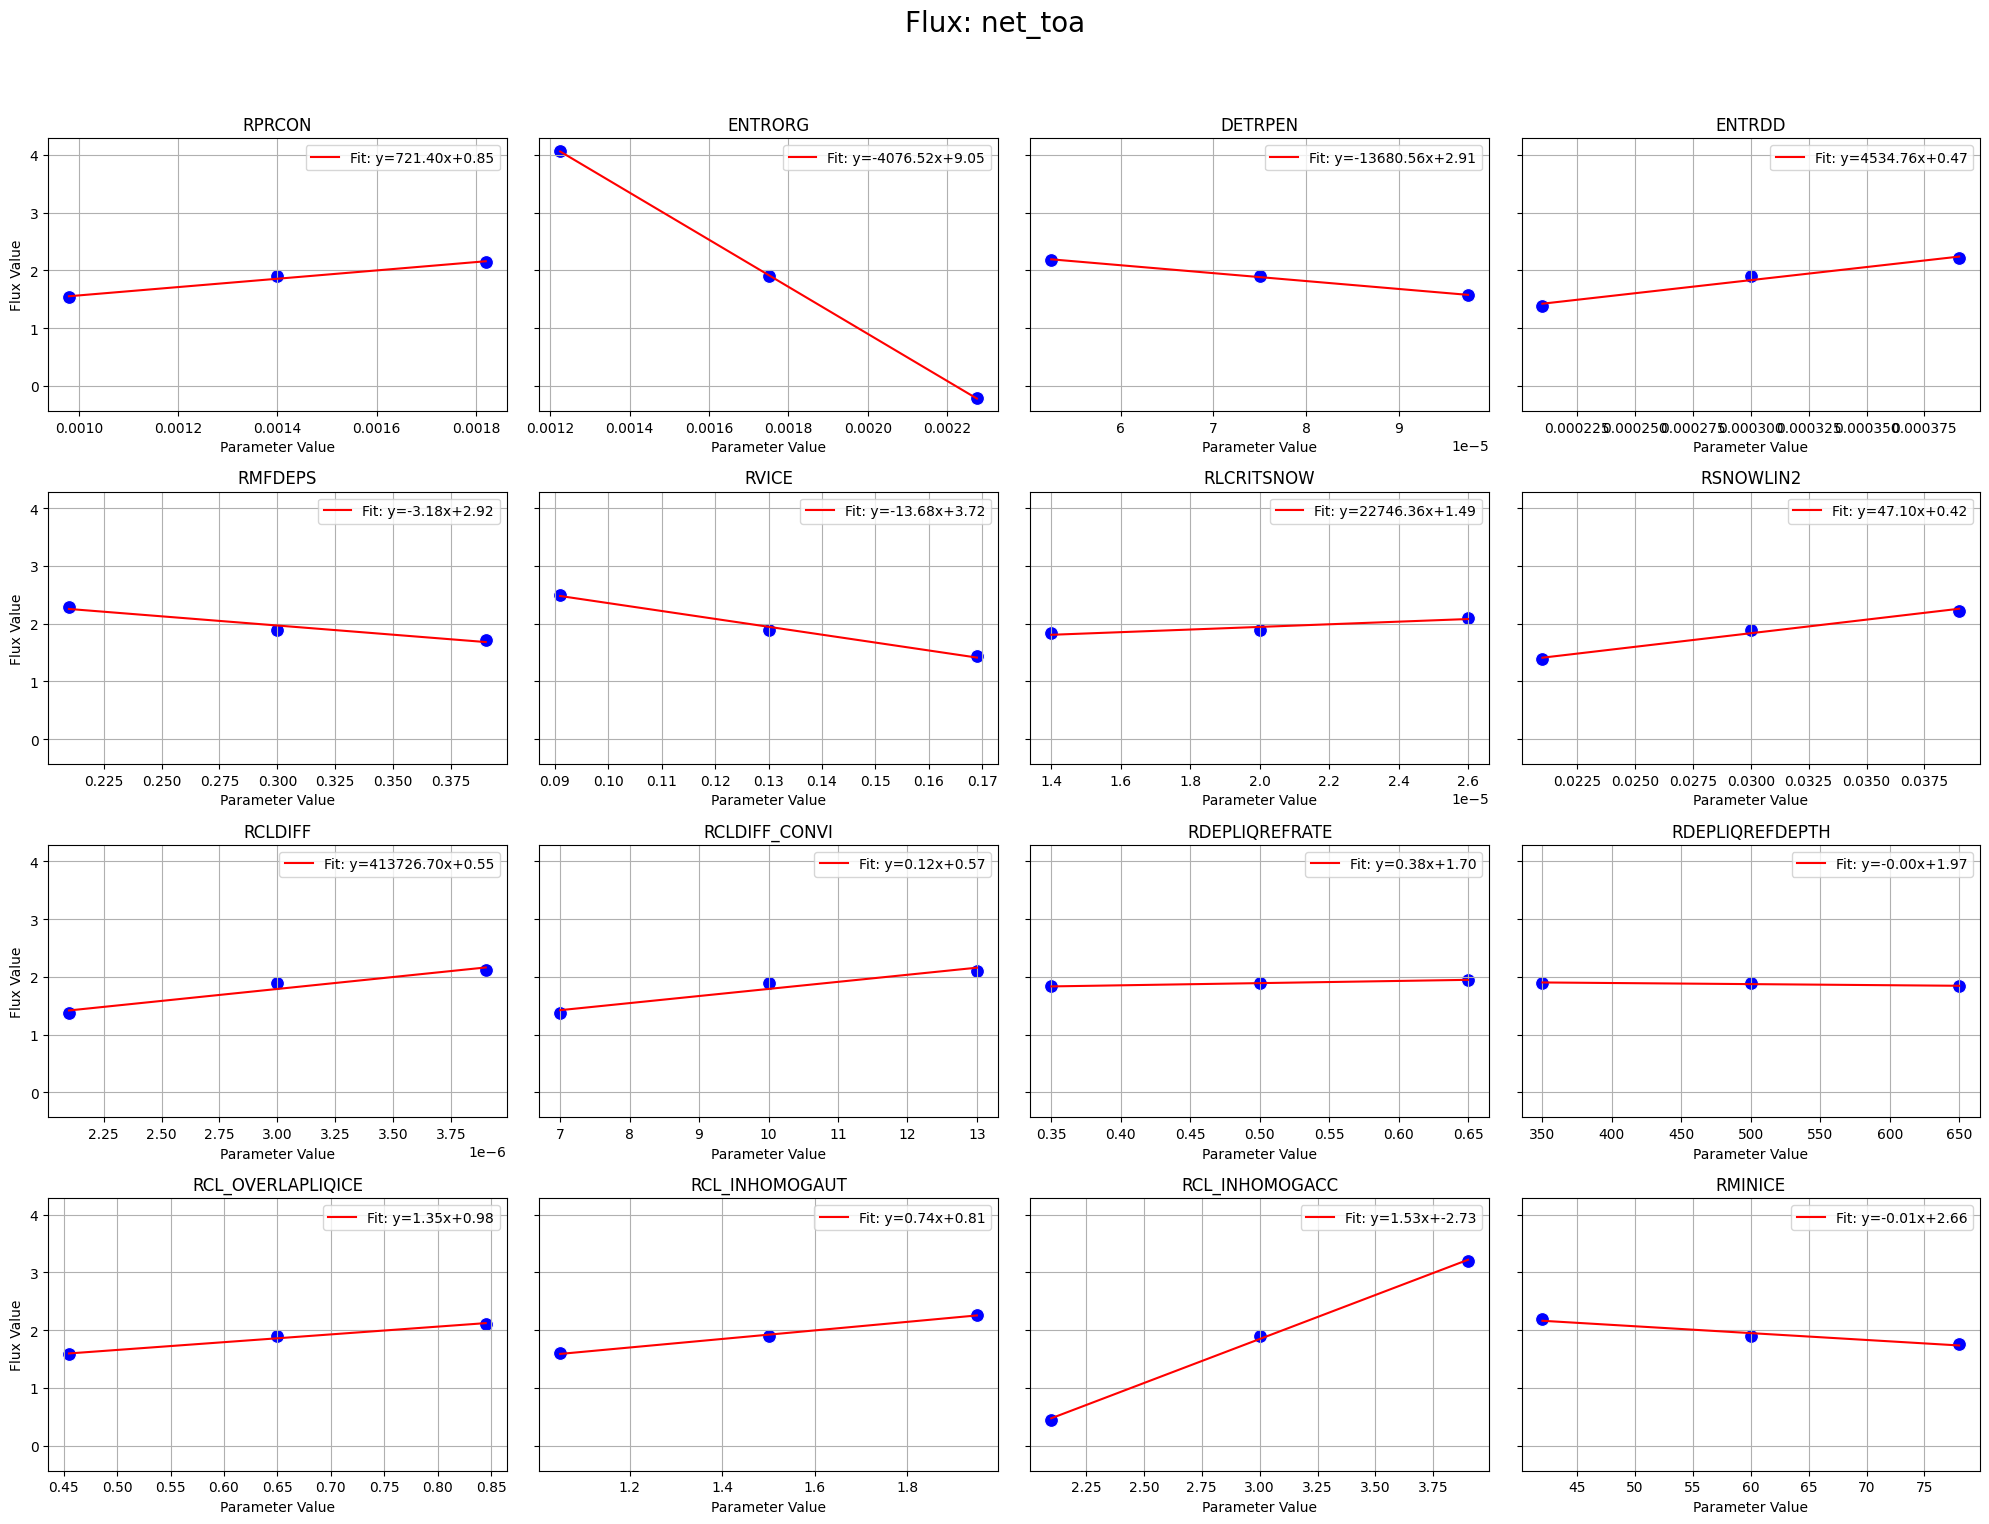

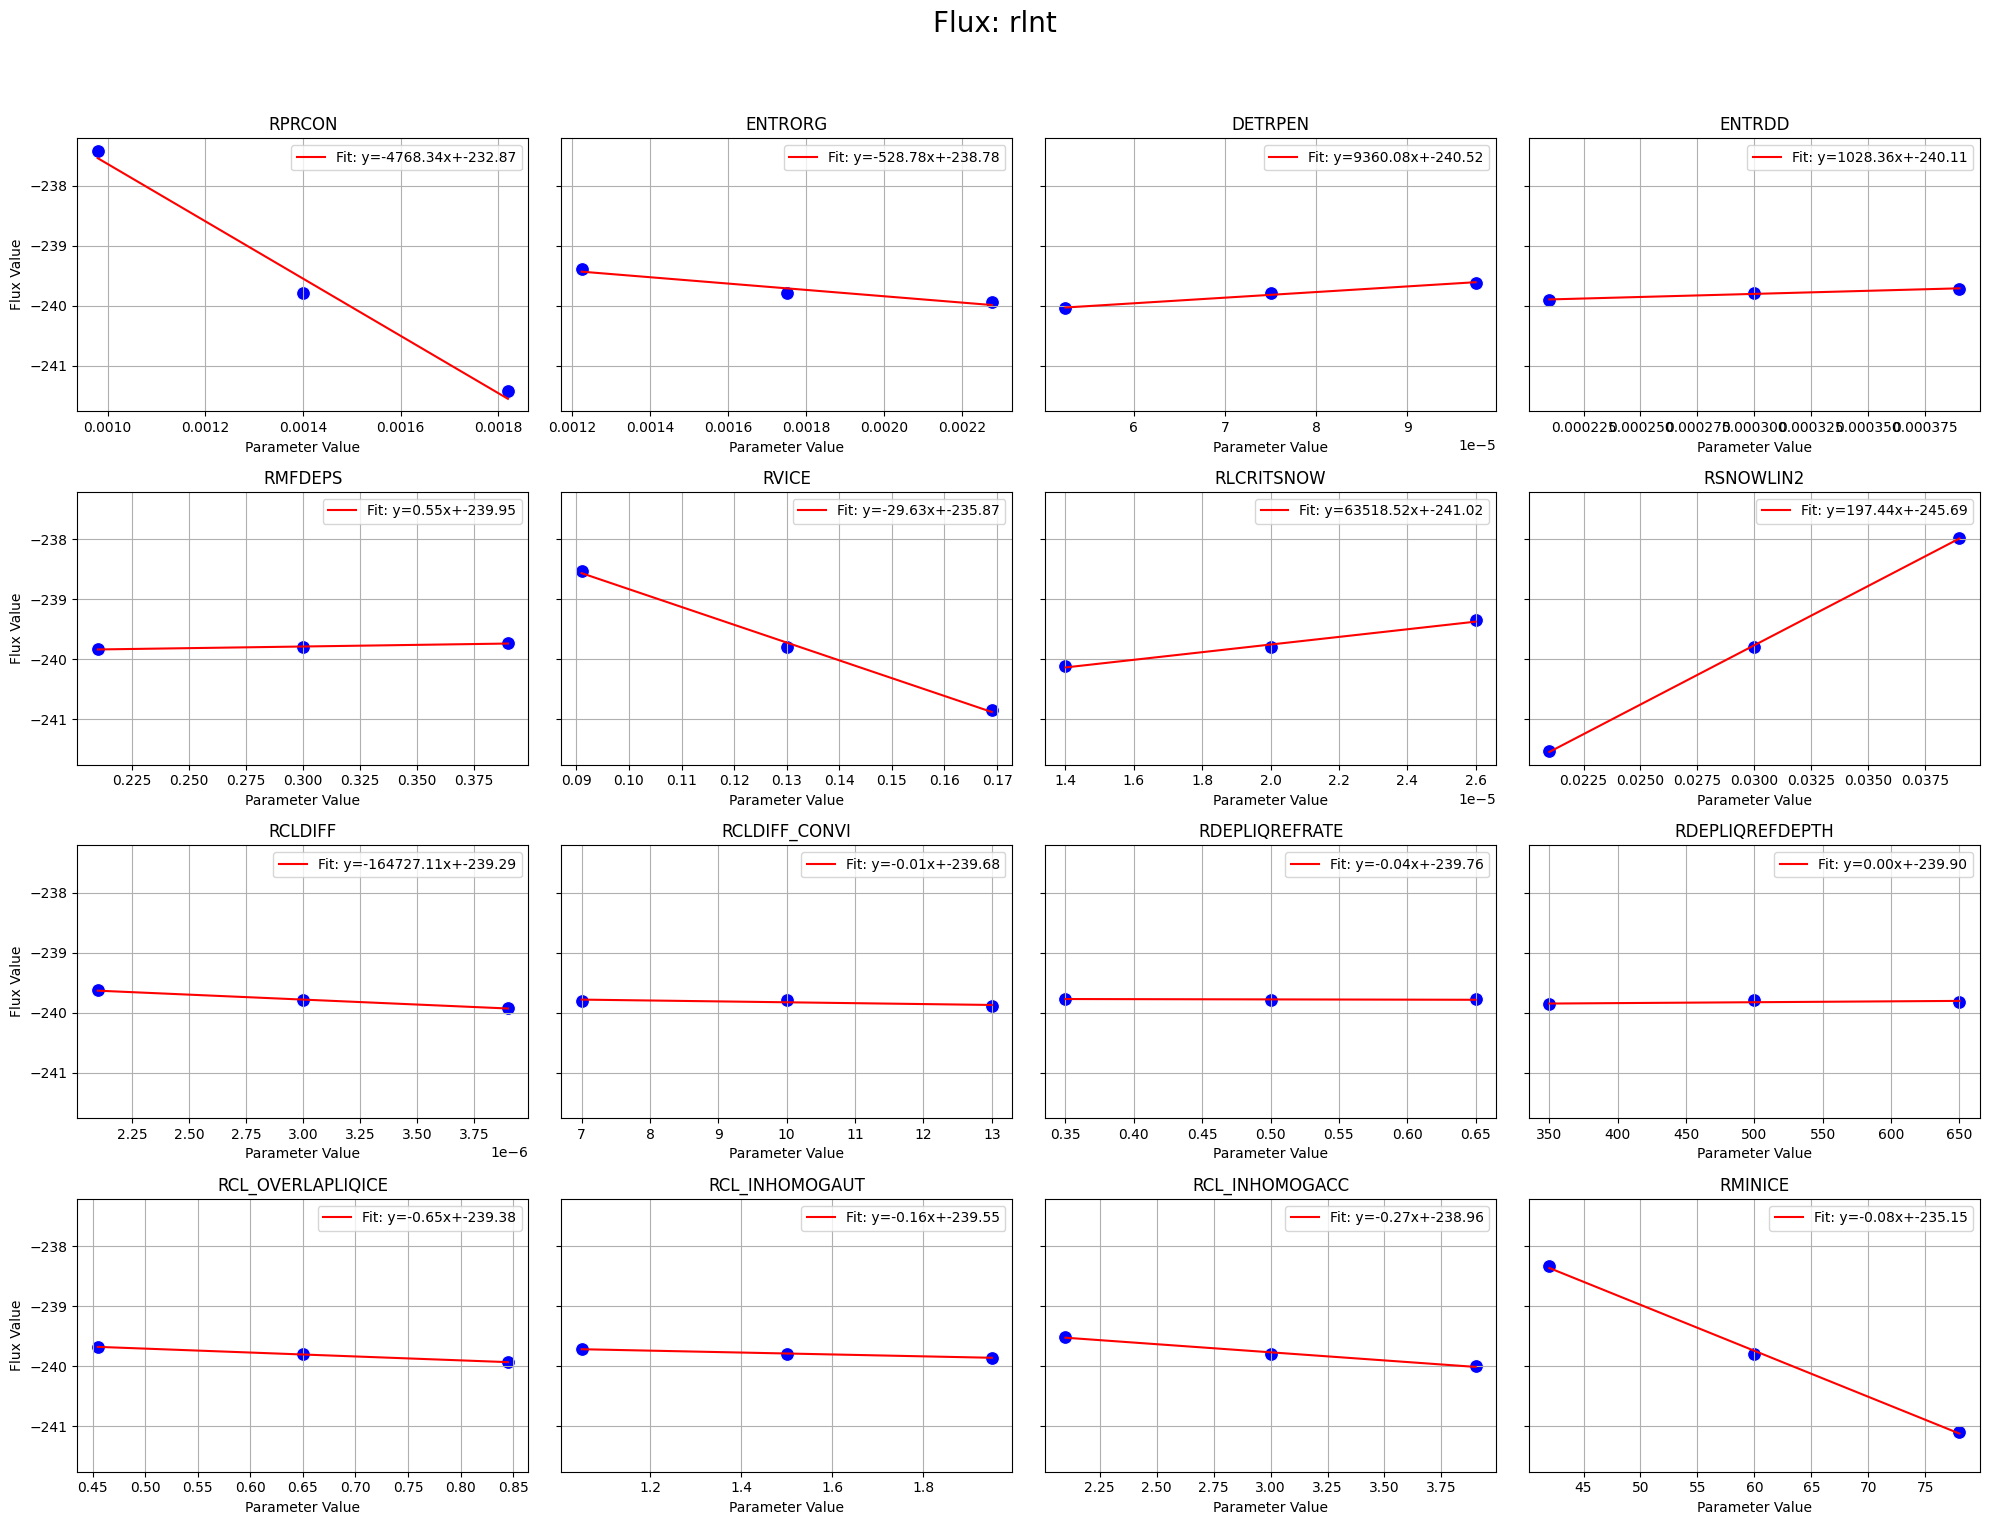

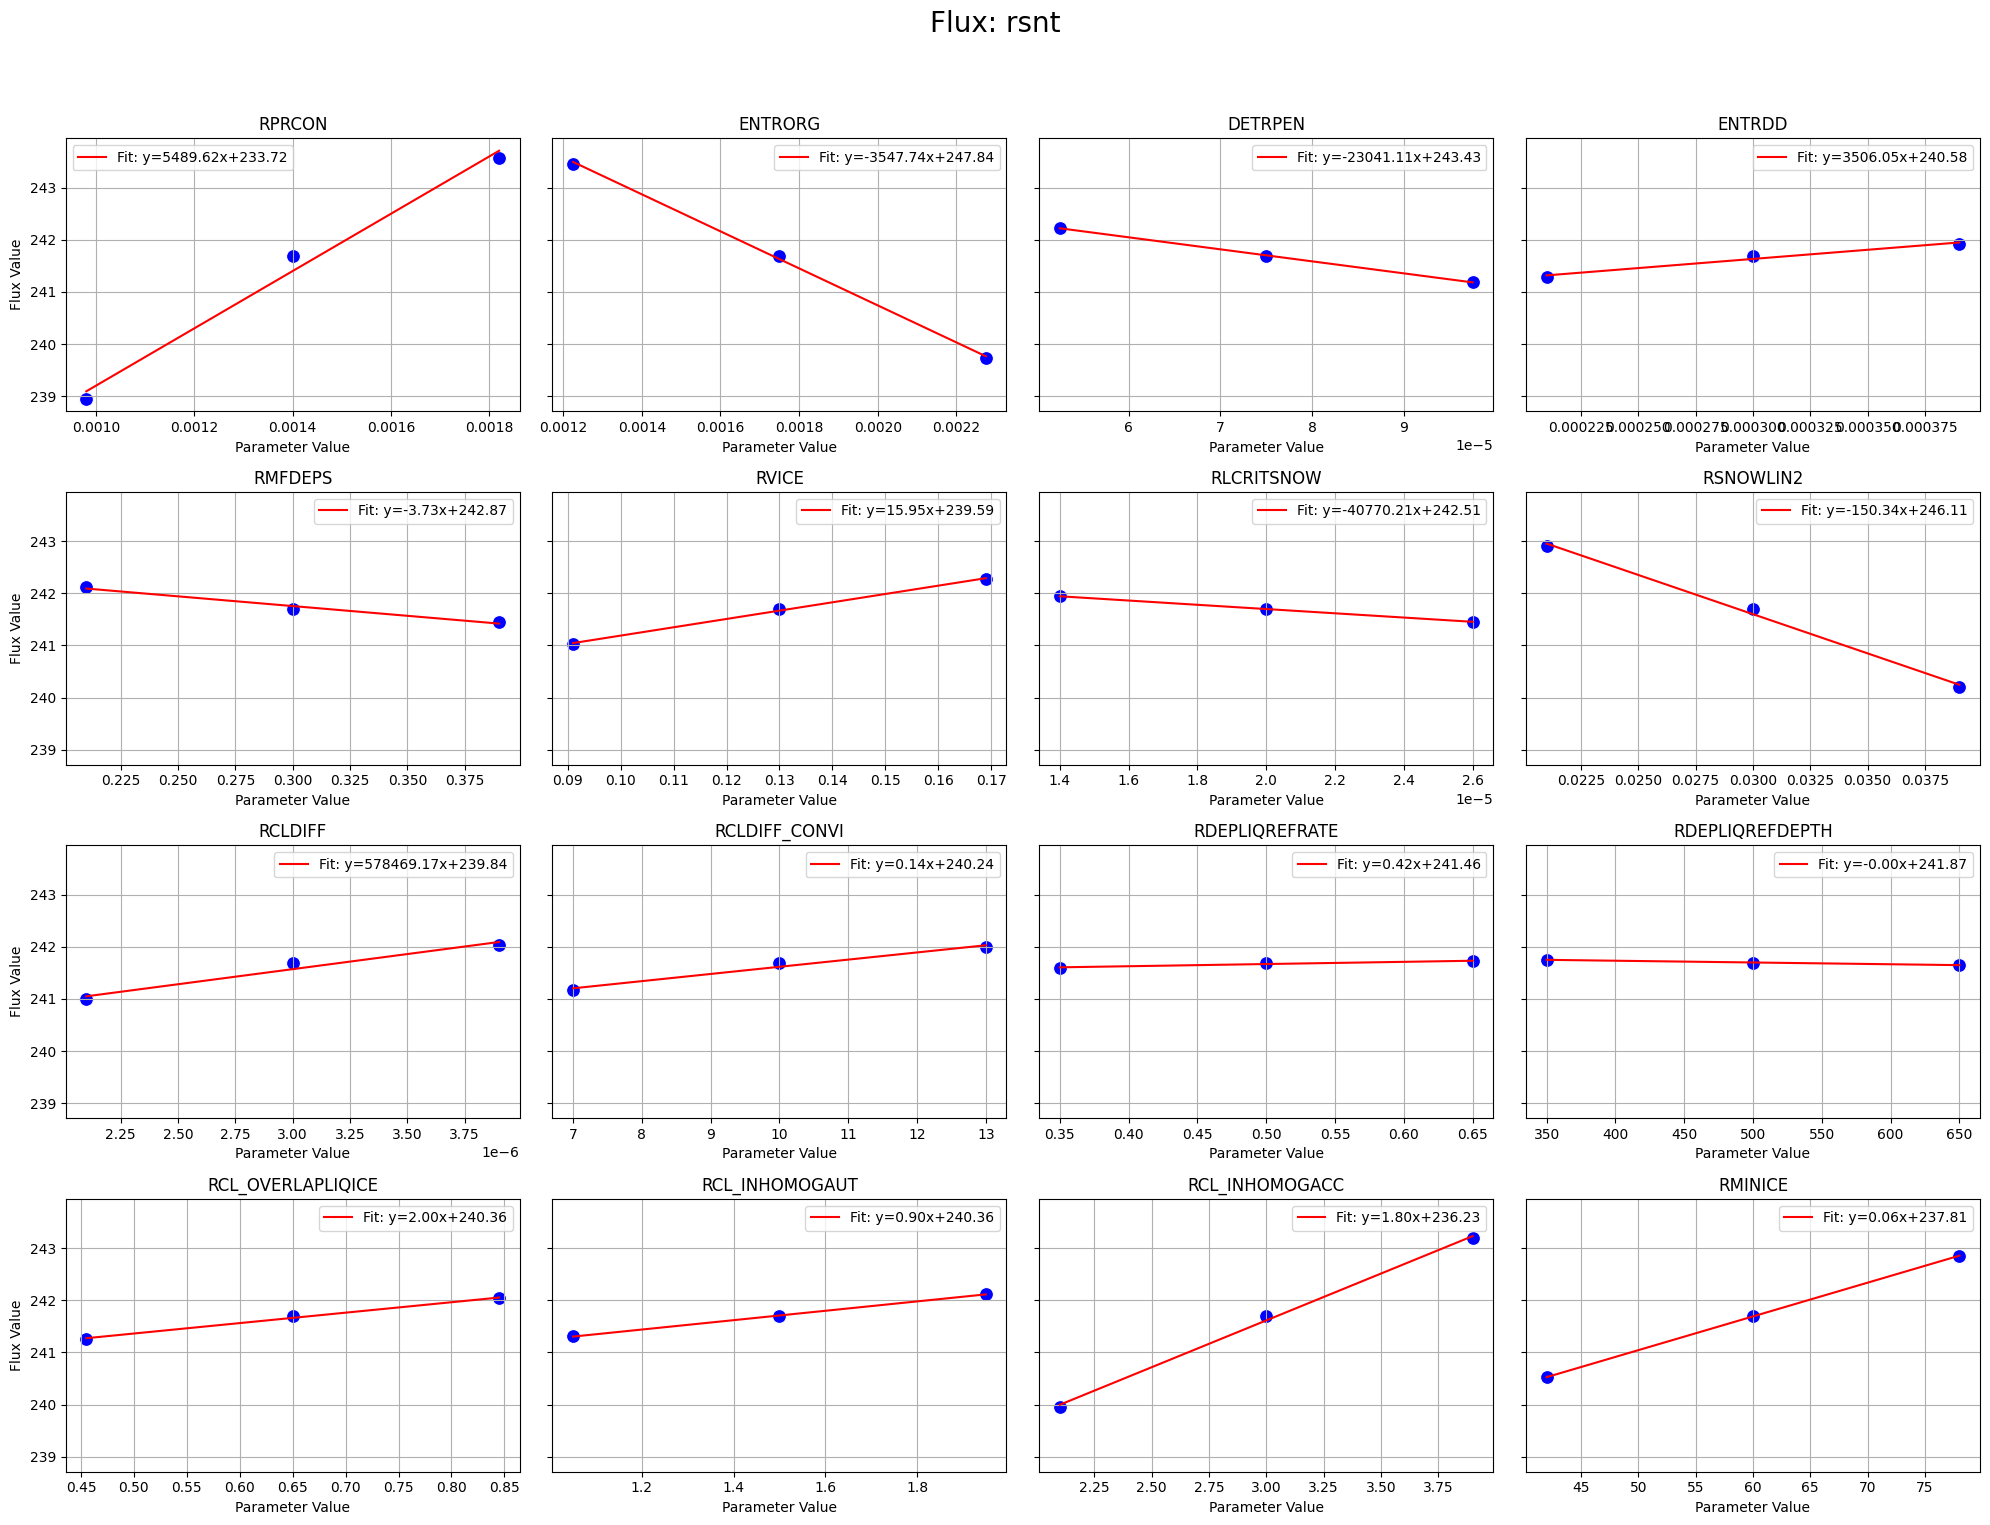

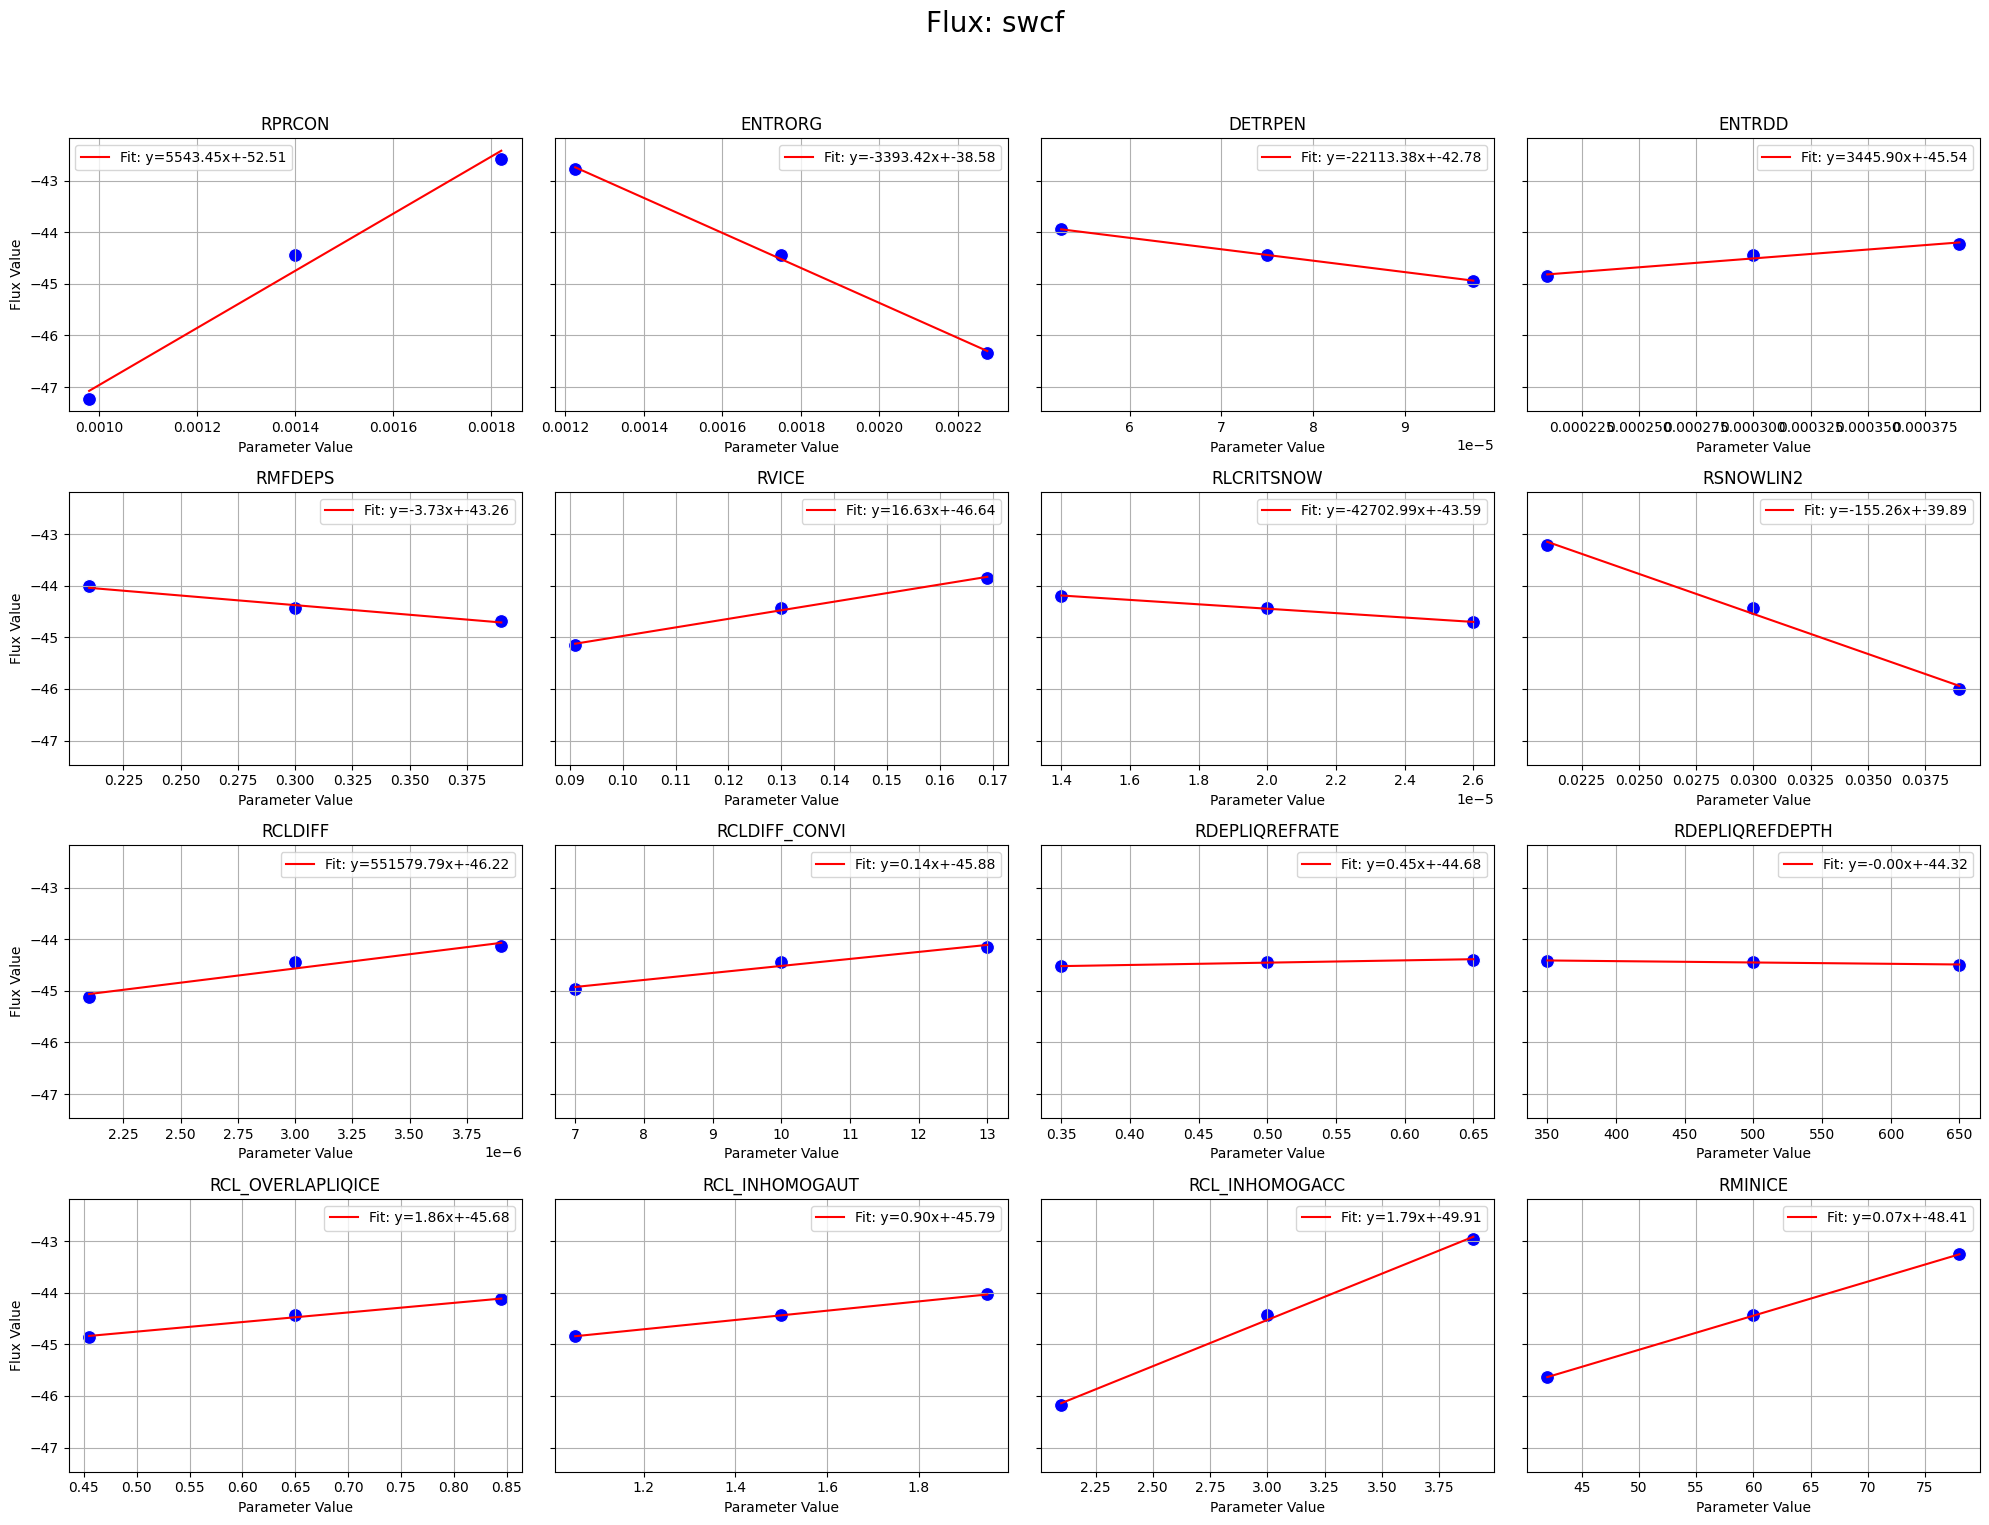

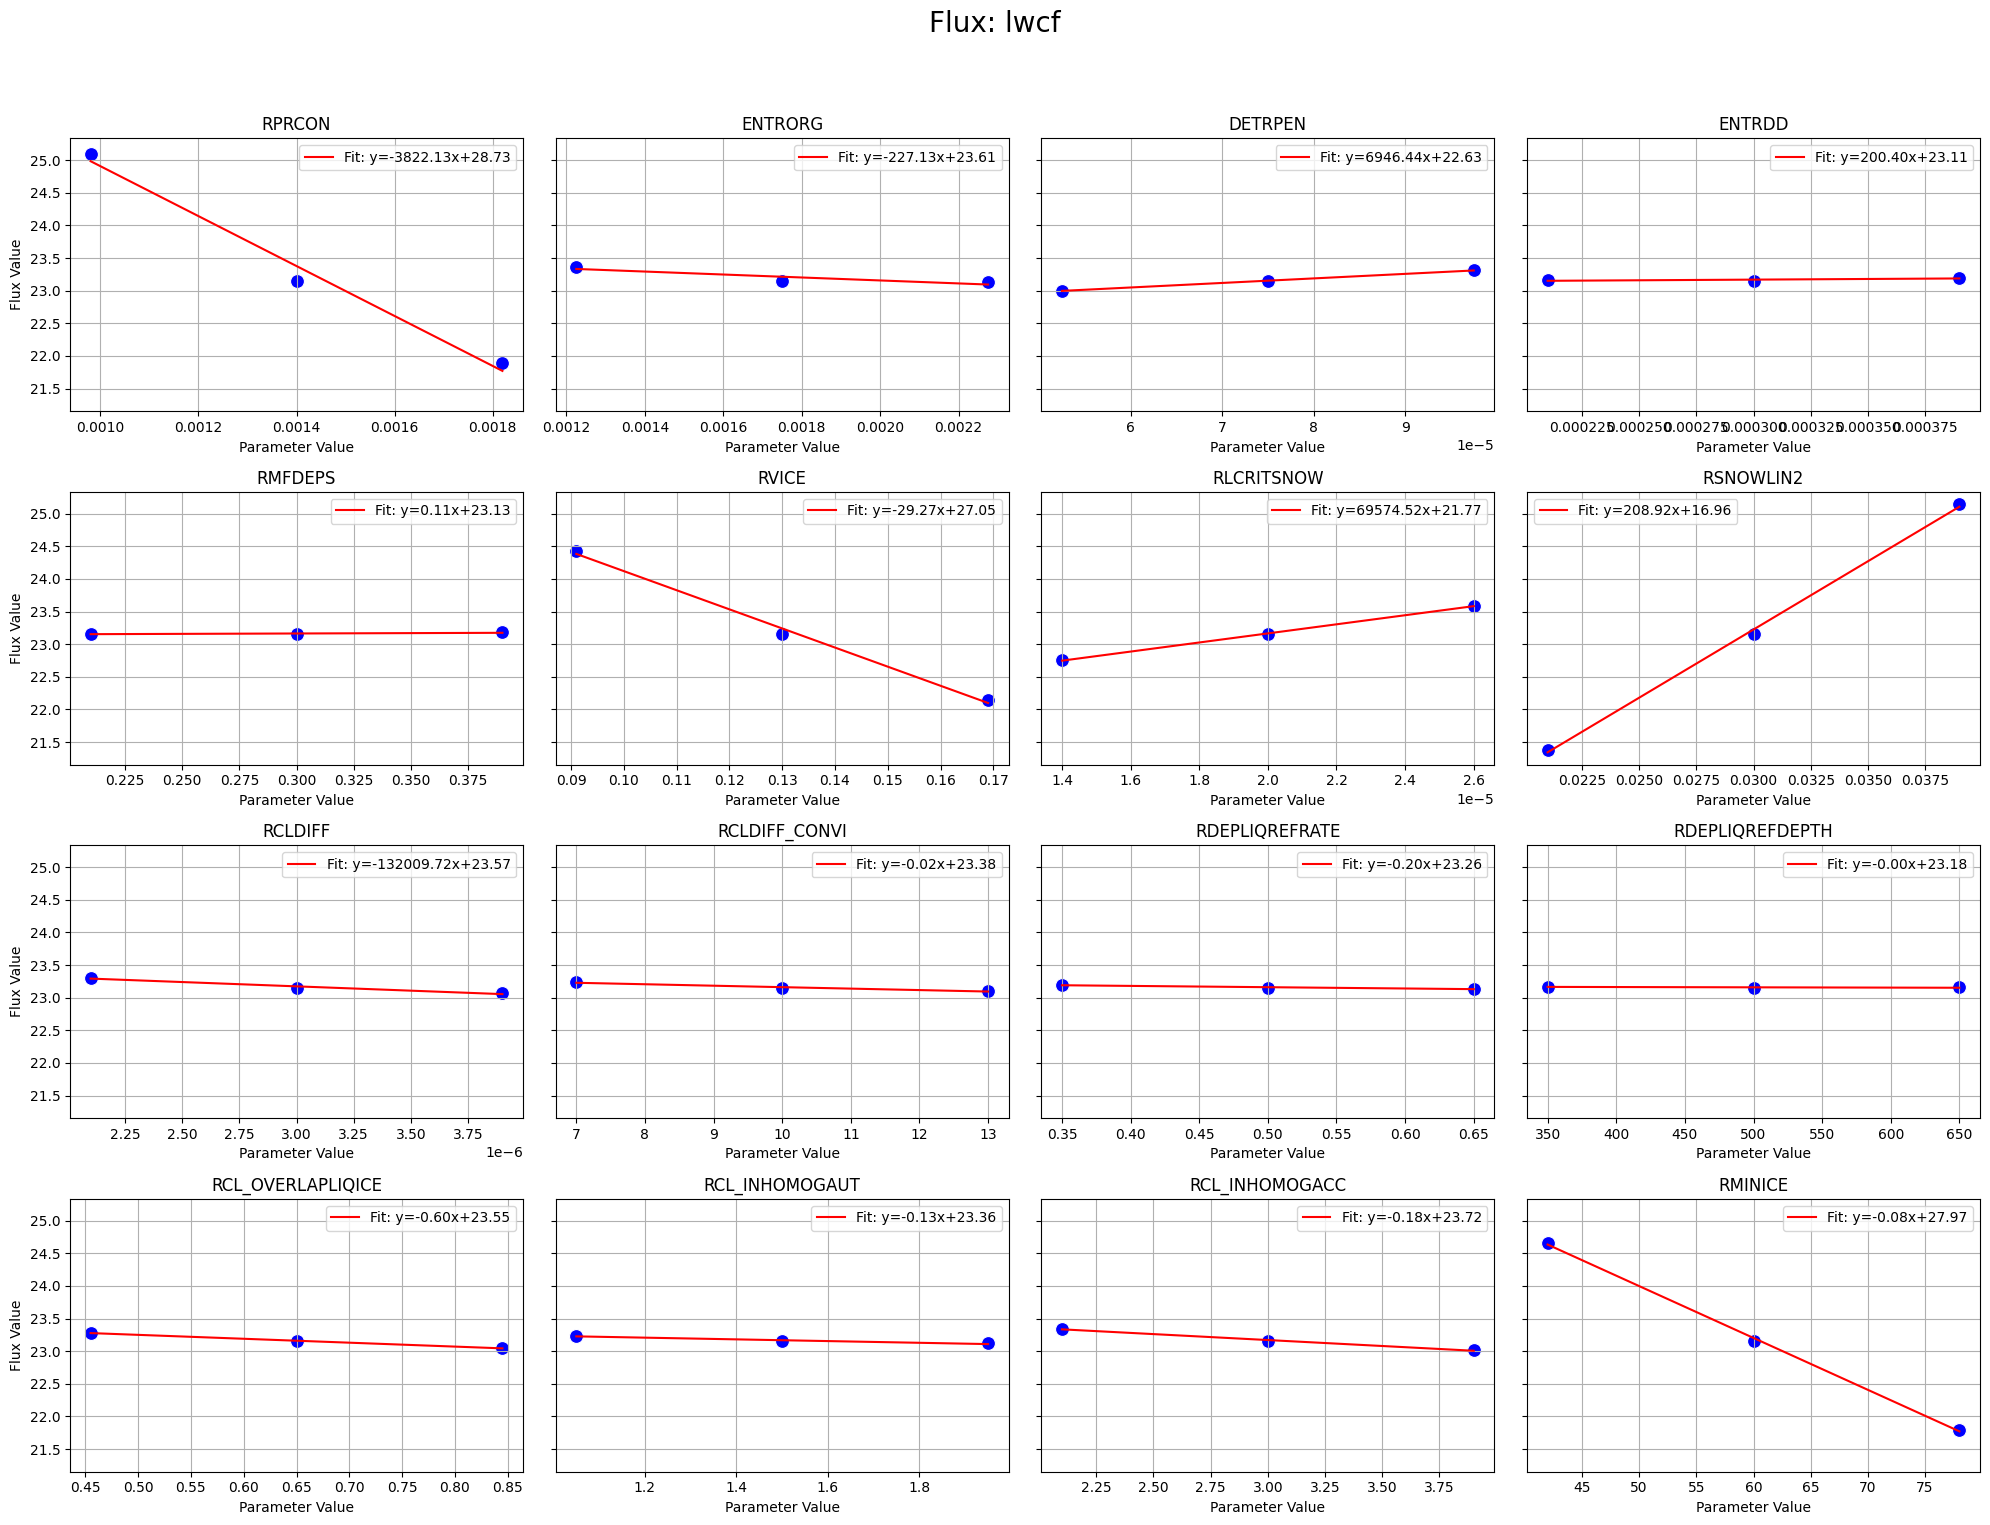

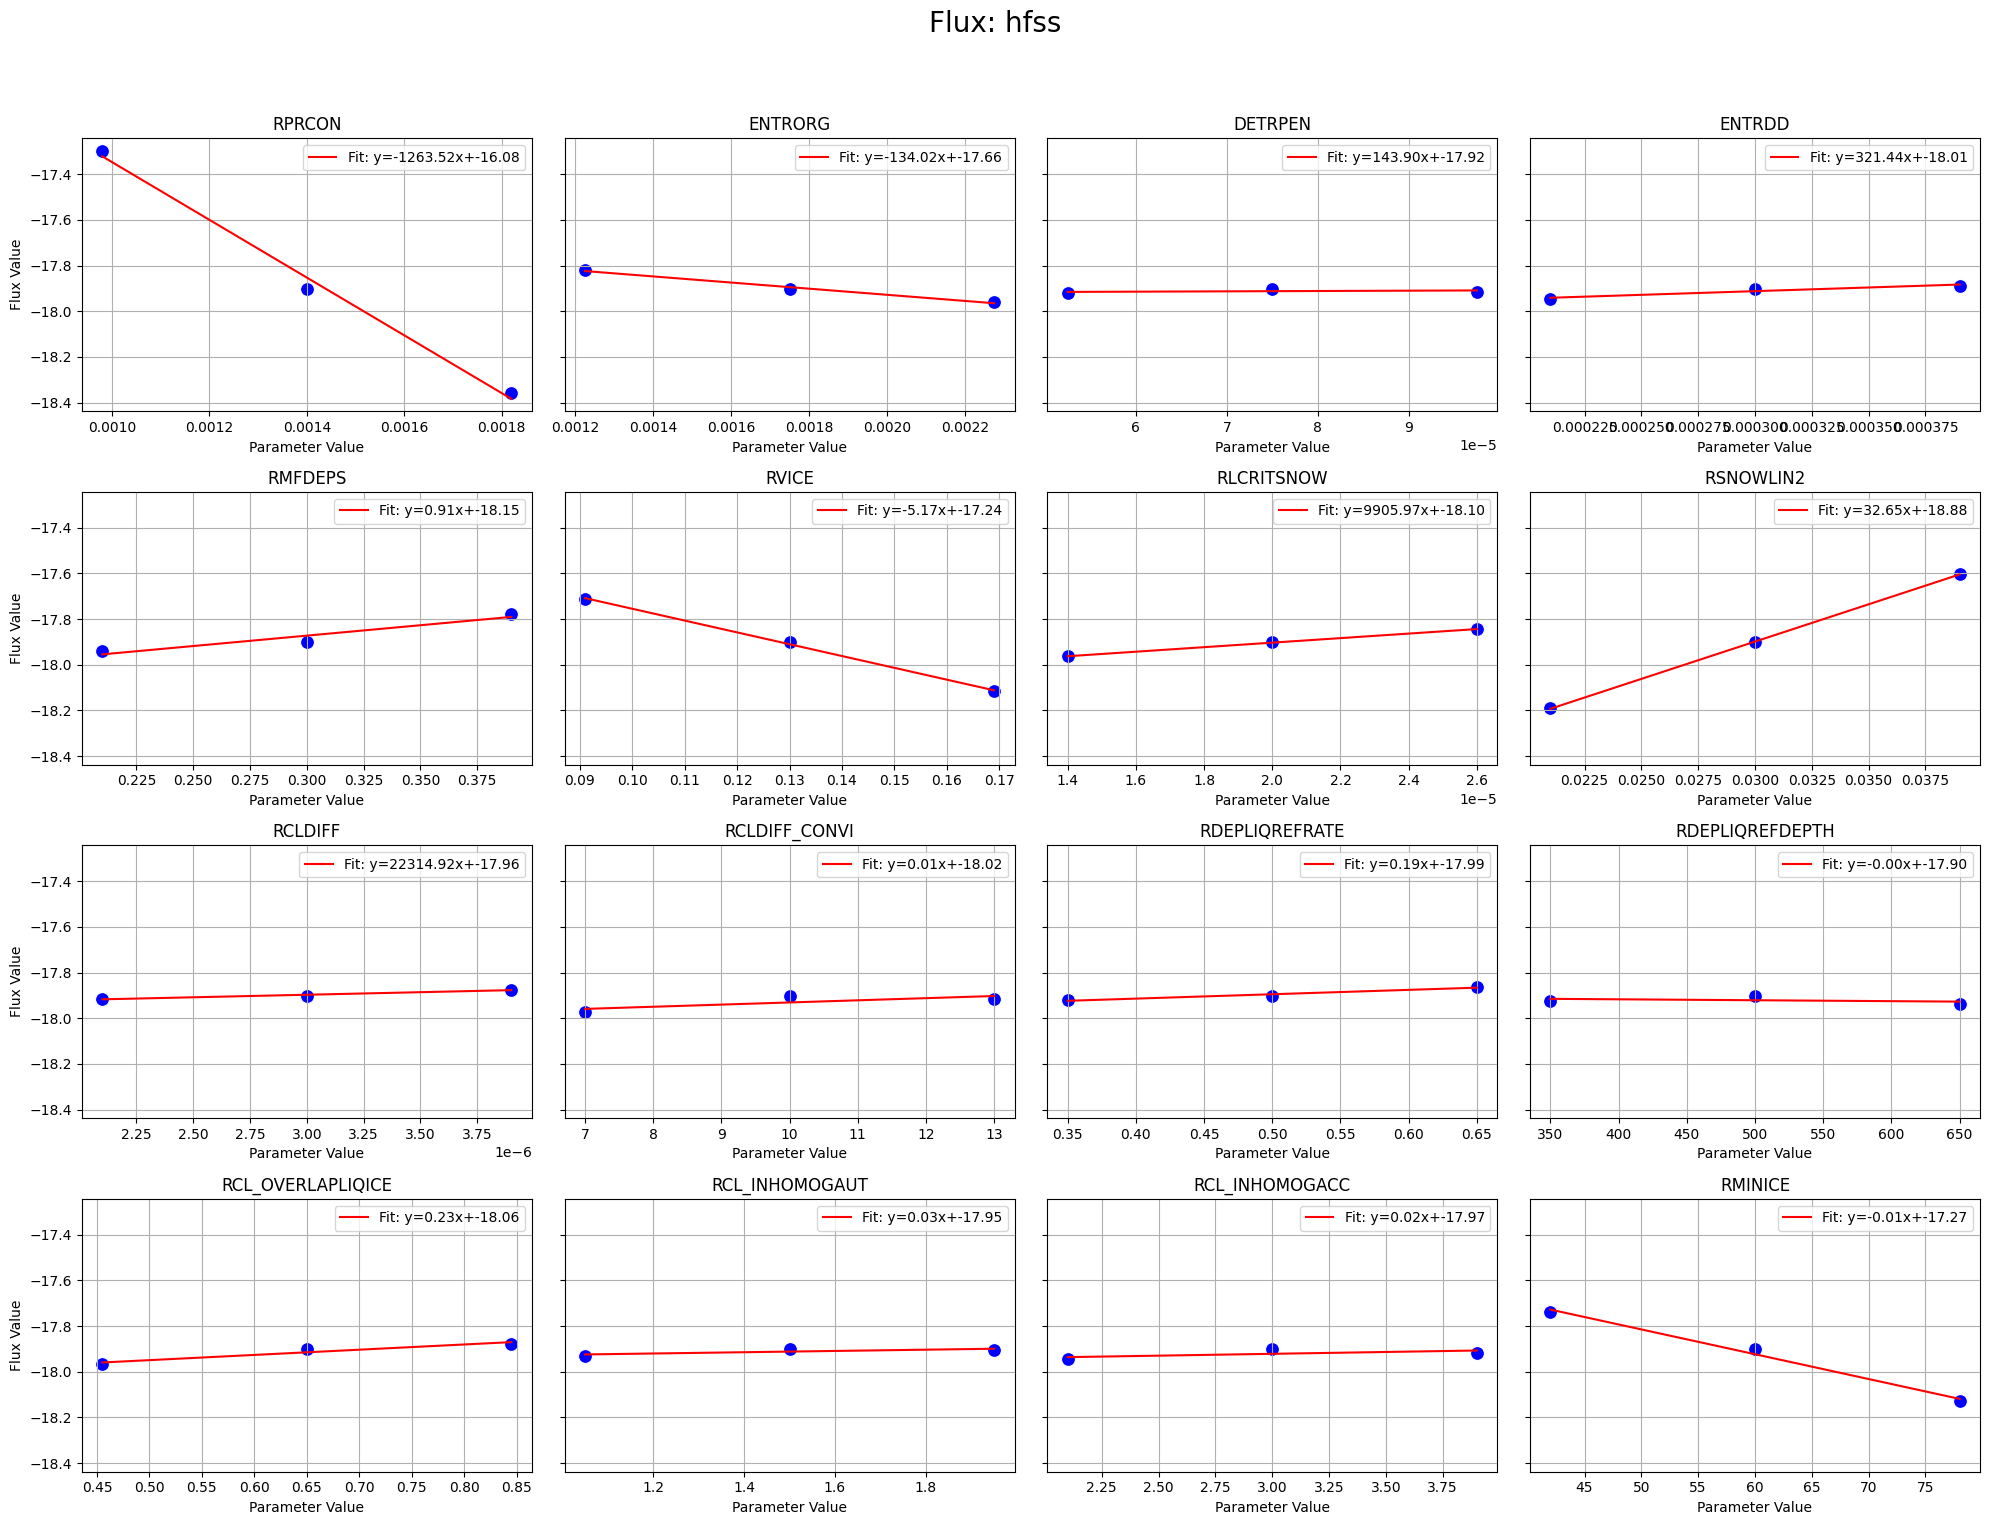

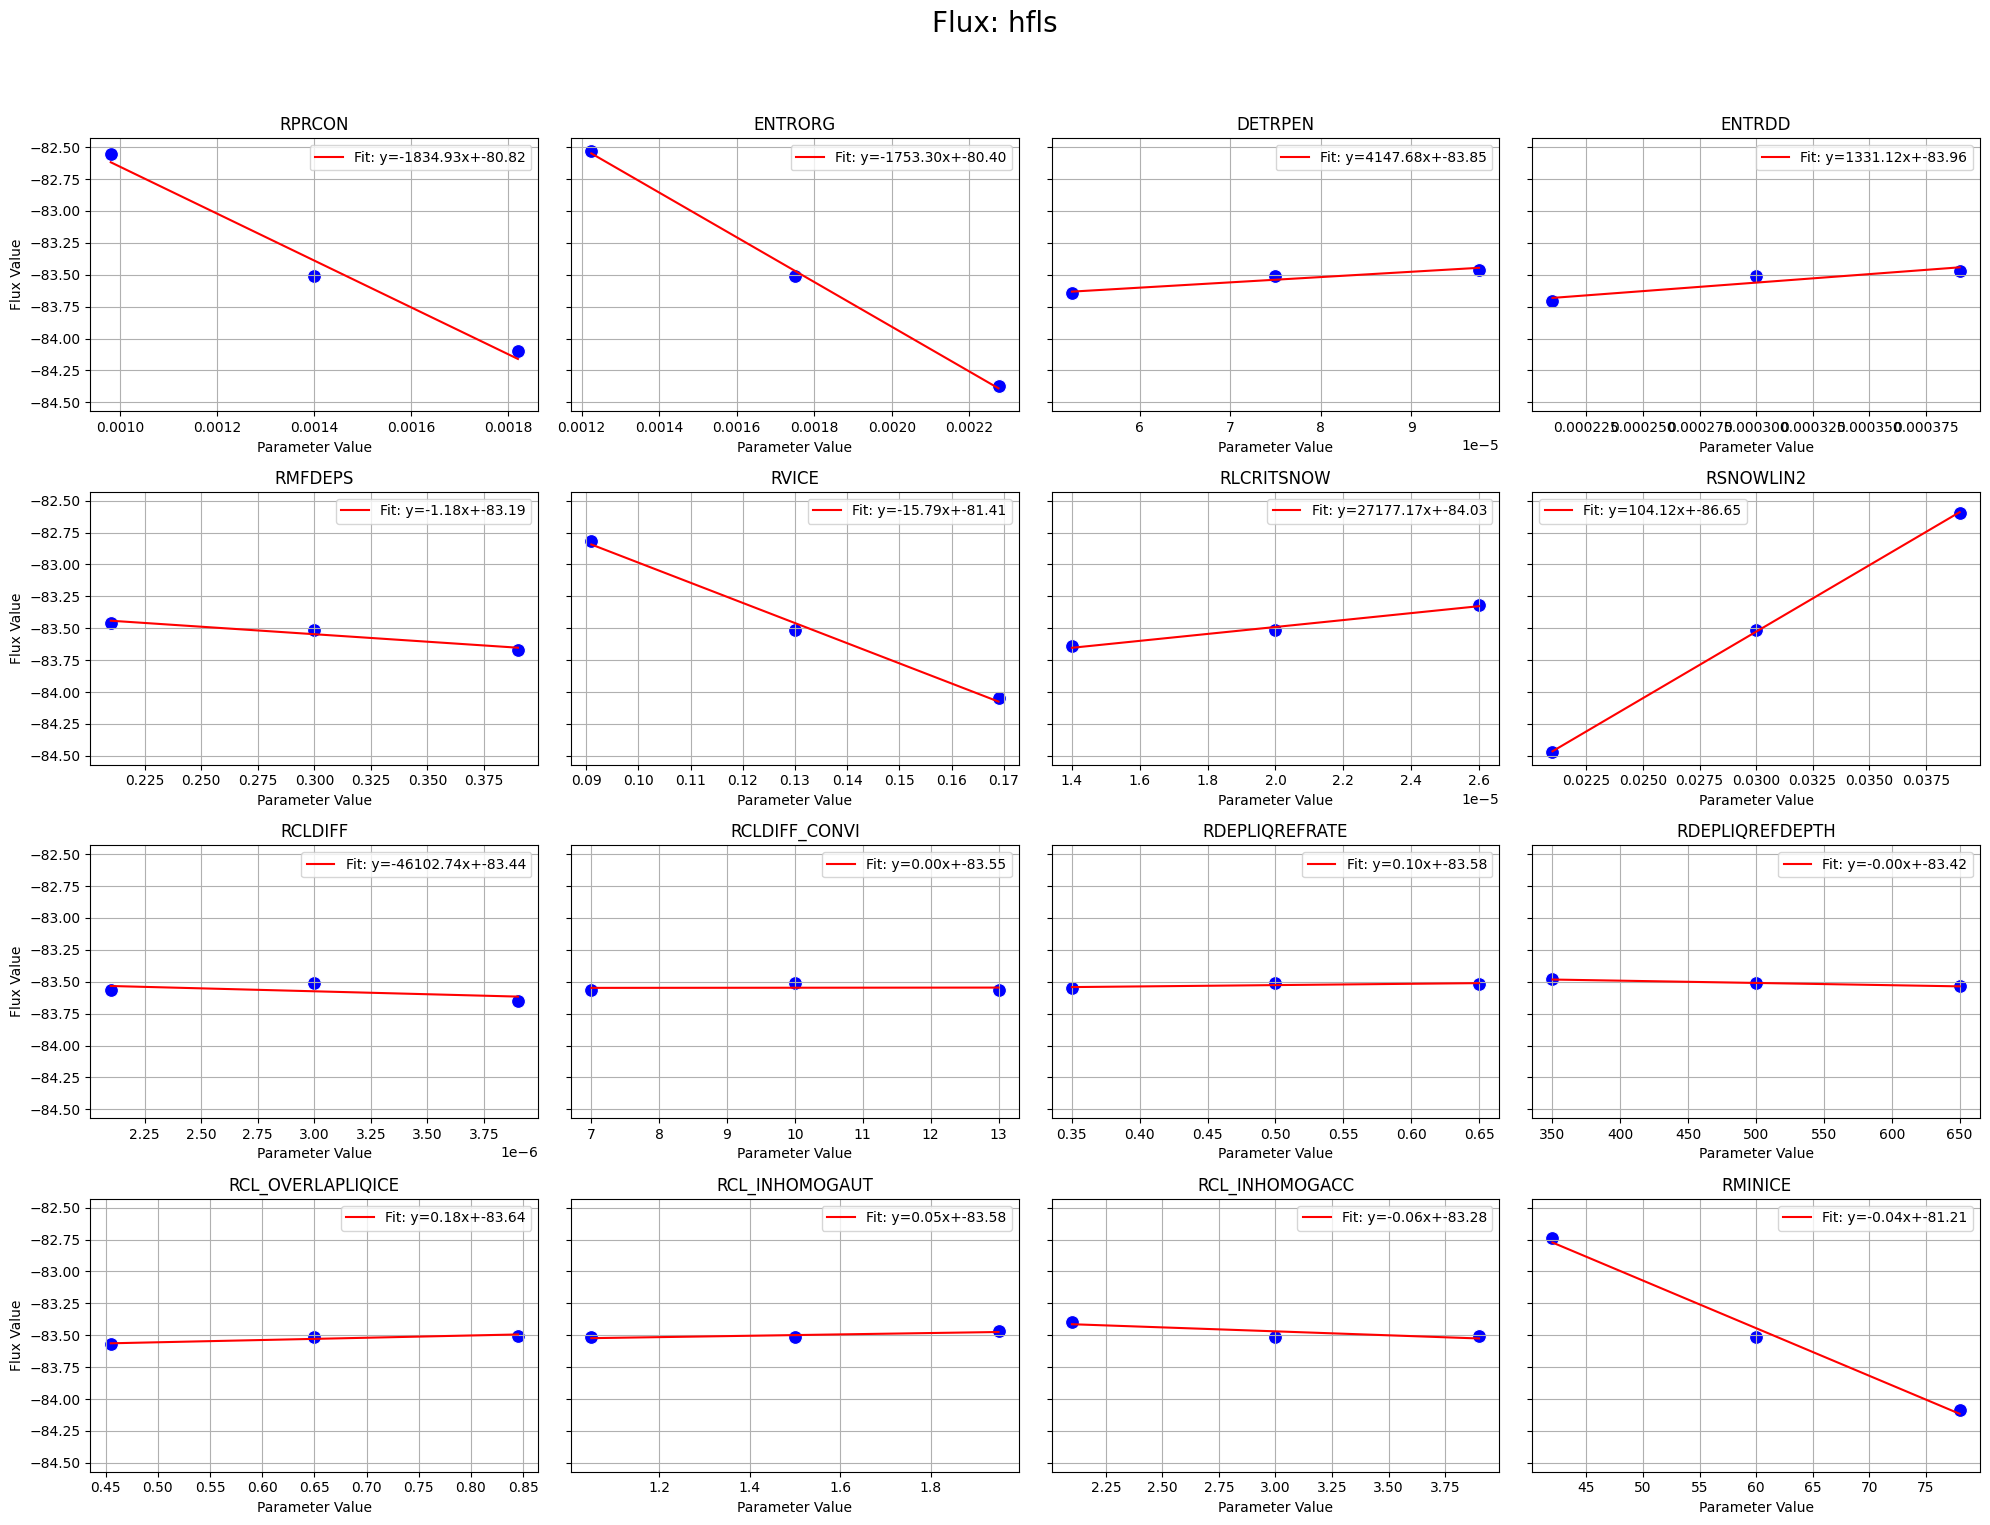

In [2]:

import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Directories
ecmean_dir = '/home/ecme3038/hpcperm/ecearth/ecearth4/ECtuner/ectuner/ecmean/gm_TL255_v2/'
exps_dir = '/home/ecme3038/hpcperm/ecearth/ecearth4/ECtuner/ectuner/perturb_exps/exps_TL255_v2/'


# Selected fluxes
selected_fluxes = ['net_toa', 'rlnt', 'rsnt', 'swcf', 'lwcf', 'hfss', 'hfls']

# Read parameter names from params_s000.yaml
params_file = os.path.join(exps_dir, 'tuning_00.yml')
with open(params_file, 'r') as file:
    params_data = yaml.safe_load(file)

parameter_names = [
    "RPRCON",
    "ENTRORG",
    "DETRPEN",
    "ENTRDD",
    "RMFDEPS",
    "RVICE",
    "RLCRITSNOW",
    "RSNOWLIN2",
    "RCLDIFF",
    "RCLDIFF_CONVI",
    "RDEPLIQREFRATE",
    "RDEPLIQREFDEPTH",
    "RCL_OVERLAPLIQICE",
    "RCL_INHOMOGAUT",
    "RCL_INHOMOGACC",
    "RMINICE"
]
num_params = len(parameter_names) 

# Initialize data dictionary
# data_dict[flux][param] = {'param_value': [], 'flux_value': []}
data_dict = {
    flux: {param: {'param_value': [], 'flux_value': []} for param in parameter_names}
    for flux in selected_fluxes
}

# Function to extract flux values from YAML
def extract_flux(filepath, fluxes):
    with open(filepath, 'r') as stream:
        try:
            content = yaml.safe_load(stream)
        except yaml.YAMLError:
            return {flux: np.nan for flux in fluxes}
    flux_values = {}
    for flux in fluxes:
        if flux in content and 'ALL' in content[flux]:
            flux_values[flux] = content[flux]['ALL'].get('Global', np.nan)
        else:
            flux_values[flux] = np.nan
    return flux_values


# Function to extract parameter value from params YAML
def extract_param(filepath, param):
    if not os.path.exists(filepath):
        return np.nan
    with open(filepath, 'r') as stream:
        try:
            content = yaml.safe_load(stream)
            # Dato che lo YAML inizia con "-", 'content' è una lista
            if not isinstance(content, list) or len(content) == 0:
                return np.nan
            
            # Navighiamo l'albero: base.context -> model_config -> oifs -> tuning
            # Usiamo .get() con dizionario vuoto {} come default per evitare crash
            base_context = content[0].get('base.context', {})
            tuning = base_context.get('model_config', {}).get('oifs', {}).get('tuning', {})
            
            # Il parametro può essere in uno di questi tre sottogruppi
            for group in ['namcumf', 'namcldp', 'naerad']:
                group_data = tuning.get(group, {})
                if param in group_data:
                    return float(group_data[param]) # Converte 0.14E-02 in float
                    
        except (yaml.YAMLError, AttributeError, TypeError):
            return np.nan
    return np.nan

# Populate data dictionary
# Populate data dictionary
for idx, param in enumerate(parameter_names):
    # Calcolo degli ID numerici basato sulla nuova progressione
    id_minus = 2 * idx + 1
    id_plus = 2 * idx + 2
    
    # Lista degli esperimenti da analizzare per questo specifico parametro
    # Usiamo il formato :03d per avere k001, k002 ecc.
    experiments = [f'k{id_minus:03d}', 'k000', f'k{id_plus:03d}']
    
    for exp in experiments:
        # 1. Gestione file dei FLUSSI (ecmean)
        # Nome file es: global_mean_k001_EC-Earth4_r1i1p1f1_1991_2001.yml
        flux_file = f'global_mean_{exp}_EC-Earth4_r1i1p1f1_1991_2000.yml'
        flux_path = os.path.join(ecmean_dir, flux_file)
        fluxes = extract_flux(flux_path, selected_fluxes)
        
        # 2. Gestione file dei PARAMETRI (exps)
        # Trasformiamo 'k001' in '01', 'k000' in '00' per il file tuning_XX.yml
        id_num = int(exp.replace('k', ''))
        params_file_name = f'tuning_{id_num:02d}.yml' 
        params_path = os.path.join(exps_dir, params_file_name)
        
        param_value = extract_param(params_path, param)
        
        # Riempimento dizionario
        for flux in selected_fluxes:
            data_dict[flux][param]['param_value'].append(param_value)
            data_dict[flux][param]['flux_value'].append(fluxes.get(flux, np.nan))


# Plotting
for flux in selected_fluxes:
    num_panels = num_params
    cols = 4
    rows = int(np.ceil(num_panels / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=False, sharey=True)
    axes = axes.flatten()
    
    for i, param in enumerate(parameter_names):
        ax = axes[i]
        param_vals = data_dict[flux][param]['param_value']
        flux_vals = data_dict[flux][param]['flux_value']
        
        # Remove NaN values
        valid = ~np.isnan(param_vals) & ~np.isnan(flux_vals)
        x = np.array(param_vals)[valid]
        y = np.array(flux_vals)[valid]
        
        if len(x) < 2:
            ax.scatter(x, y, color='blue', label='Data Points')
            ax.set_title(f'{param}')
            ax.set_xlabel('Parameter Value')
            ax.set_ylabel('Flux Value')
            ax.legend()
            ax.grid(True)
            continue
        
        # Scatter plot
        sns.scatterplot(x=x, y=y, ax=ax, s=100, color='blue', label=None)#label='Data Points')
        
        # Linear fit
        slope, intercept = np.polyfit(x, y, 1)
        fit_x = np.linspace(min(x), max(x), 100)
        fit_y = slope * fit_x + intercept
        ax.plot(fit_x, fit_y, color='red', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        
        # Customize axes
        ax.set_title(f'{param}')
        ax.set_xlabel('Parameter Value')
        ax.set_ylabel('Flux Value')
        ax.legend()
        ax.grid(True)
    
    # Hide any unused subplots
    for j in range(num_panels, rows*cols):
        fig.delaxes(axes[j])
    
    plt.suptitle(f'Flux: {flux}', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    # Save each figure
    fig.savefig(f'/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/plots/sensitivities/TL255v2_{flux}.png')

<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:90: SyntaxWarning: invalid escape sequence '\p'
/etc/ecmwf/ssd/ssd1/tmpdirs/ecme3038.3872913.20260224_142455.397/ipykernel_506597/1798742839.py:90: SyntaxWarning: invalid escape sequence '\p'
  capsize=4, elinewidth=2, markeredgewidth=2, label='Data $\pm$ std')


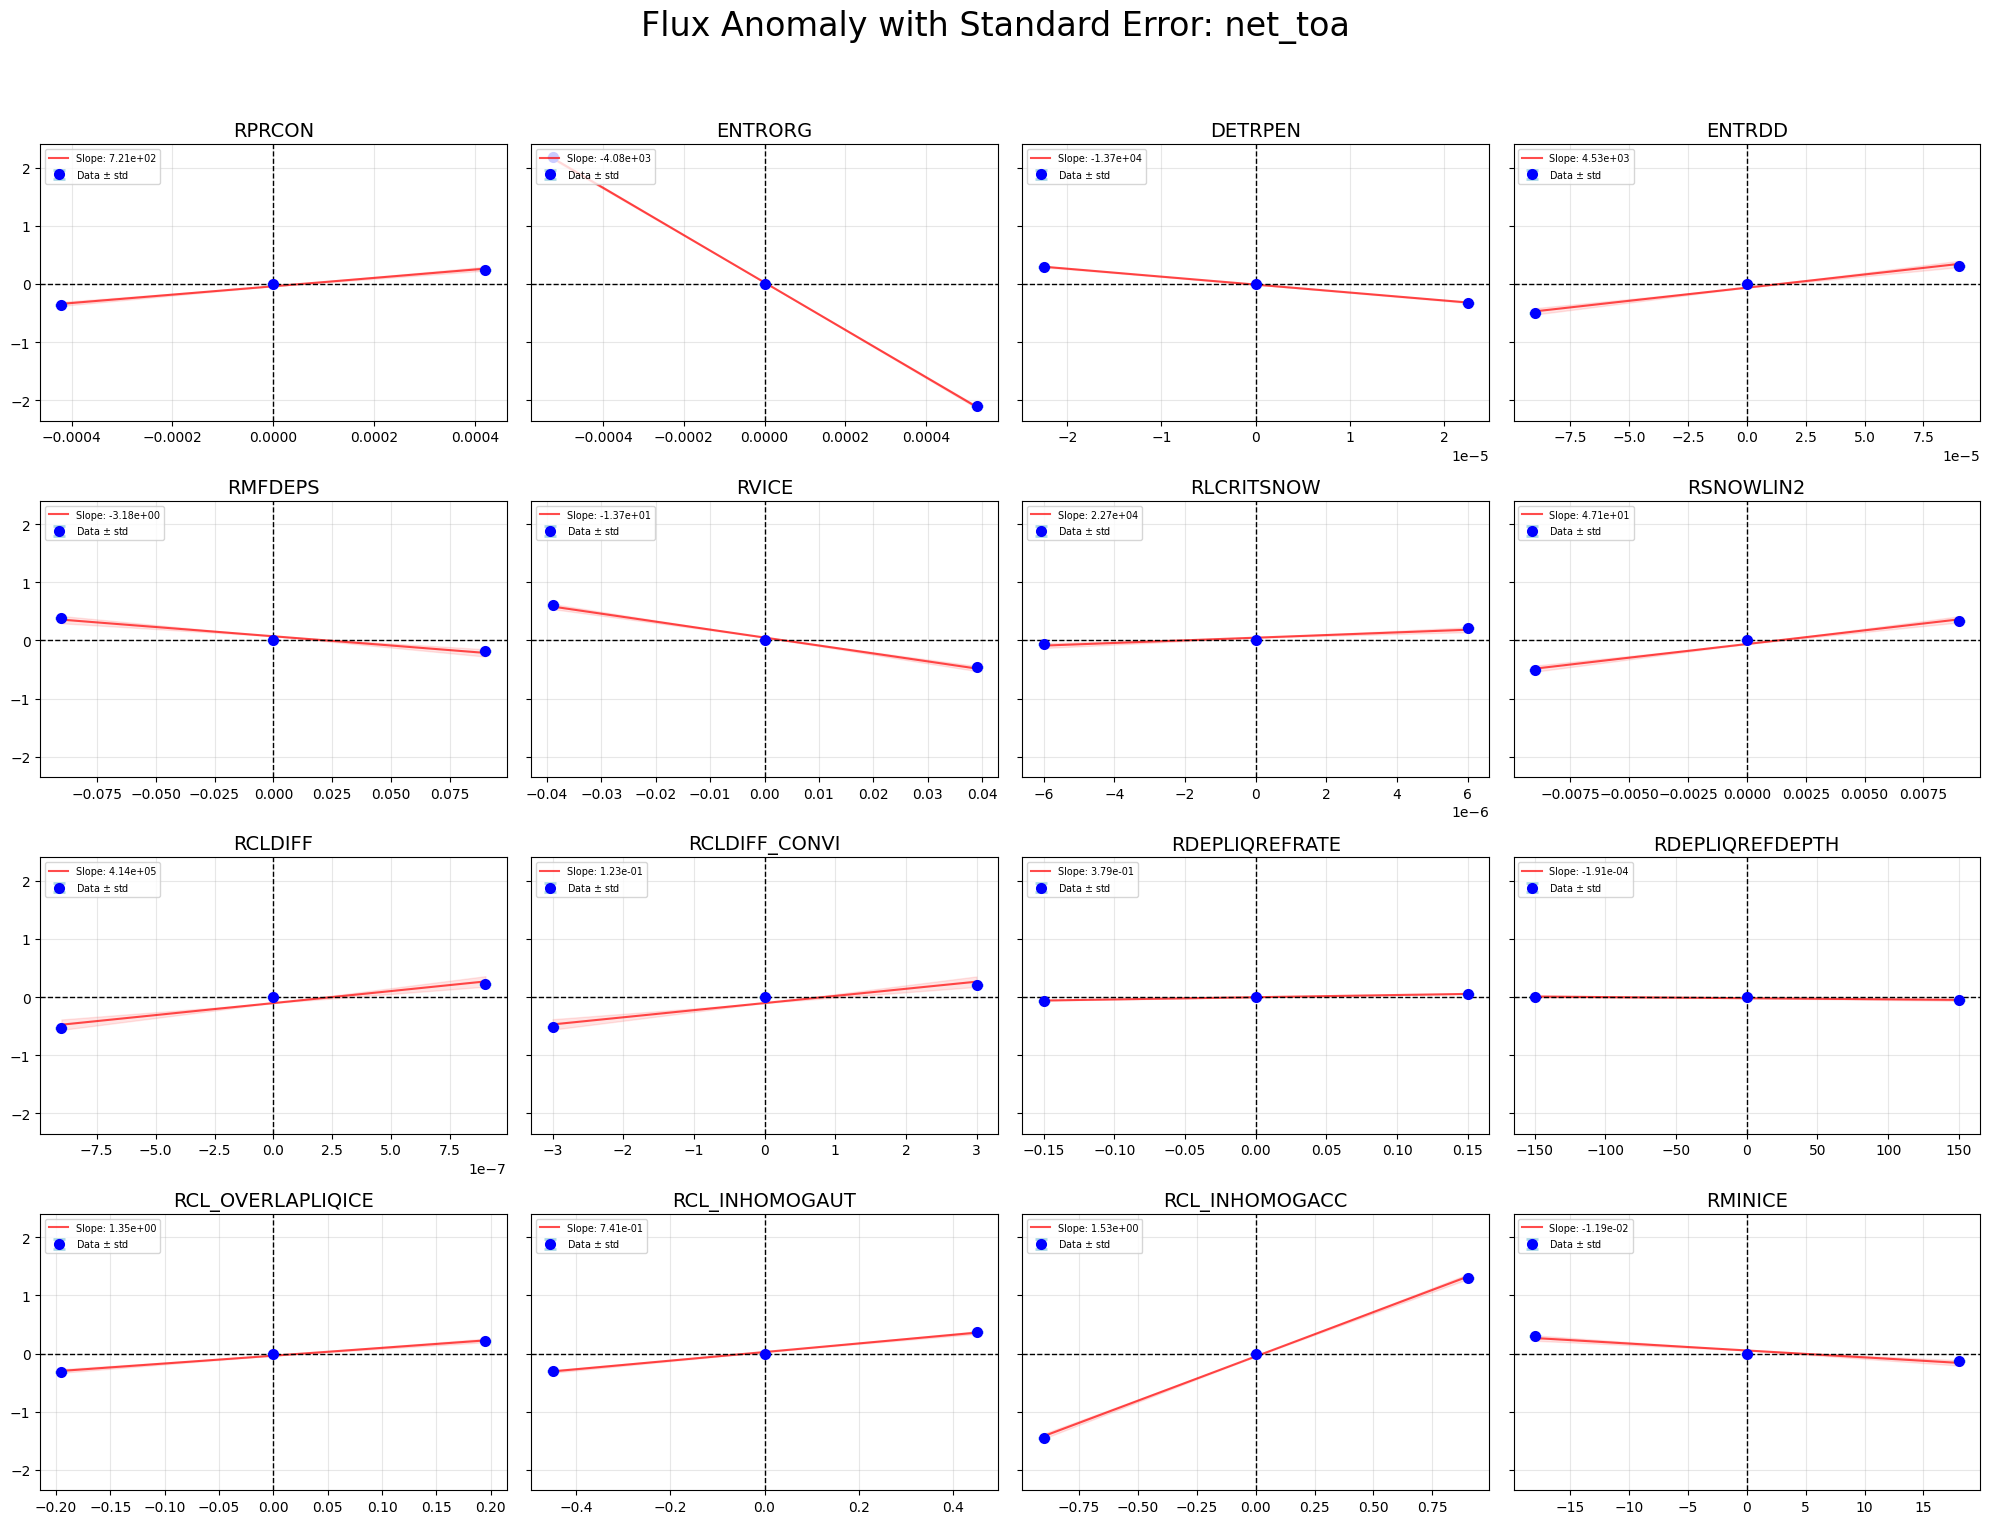

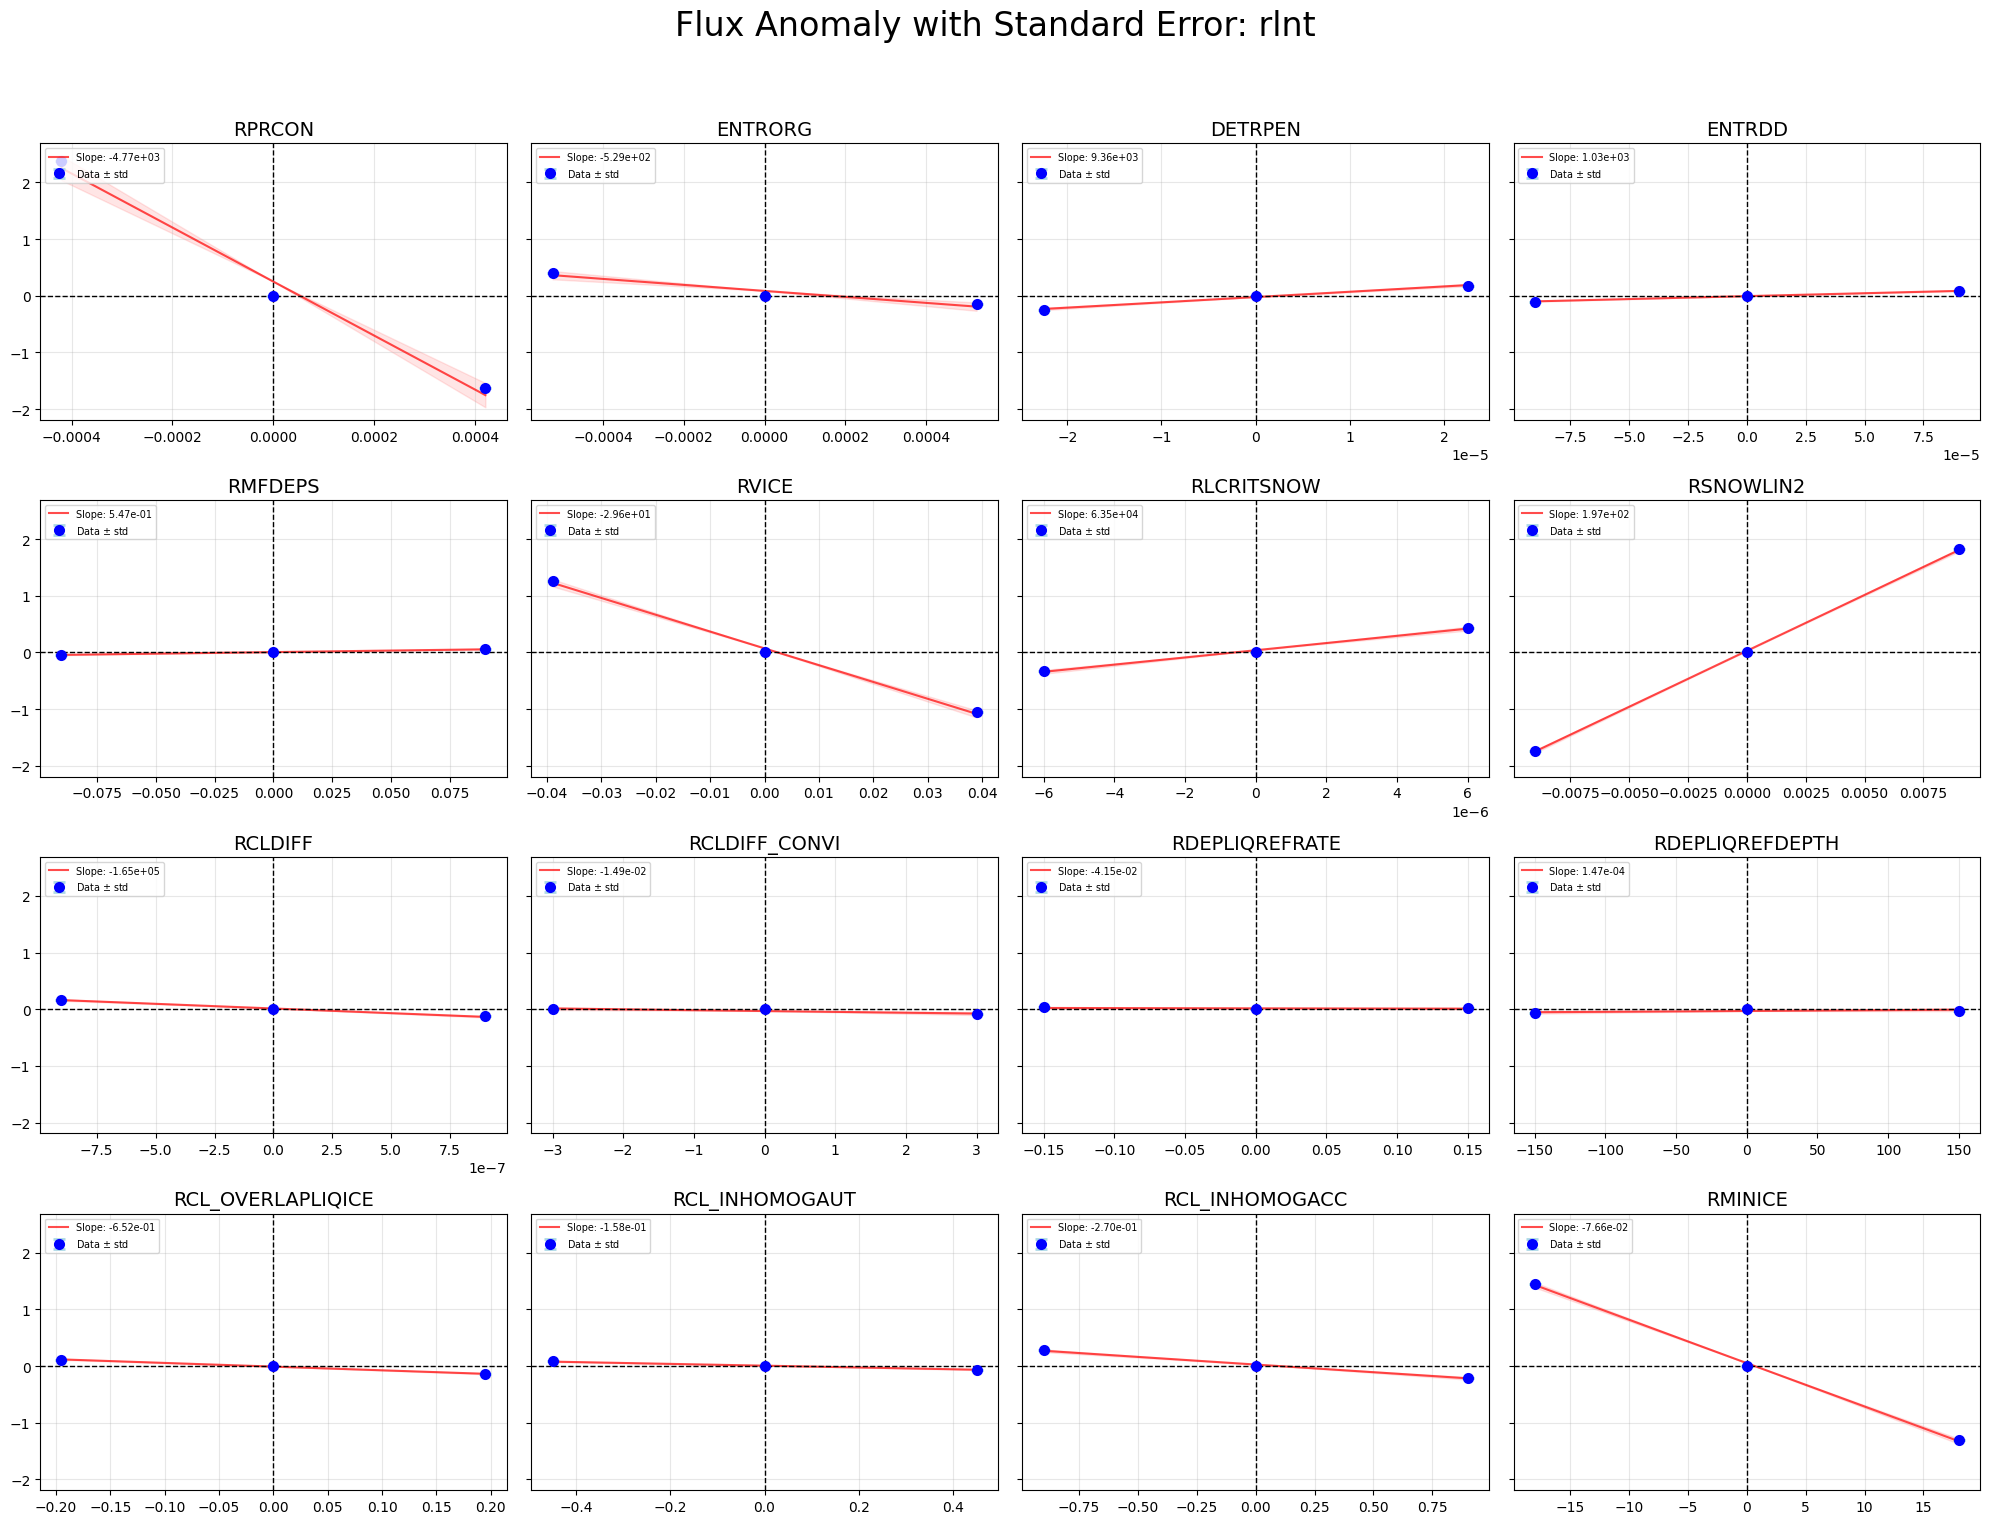

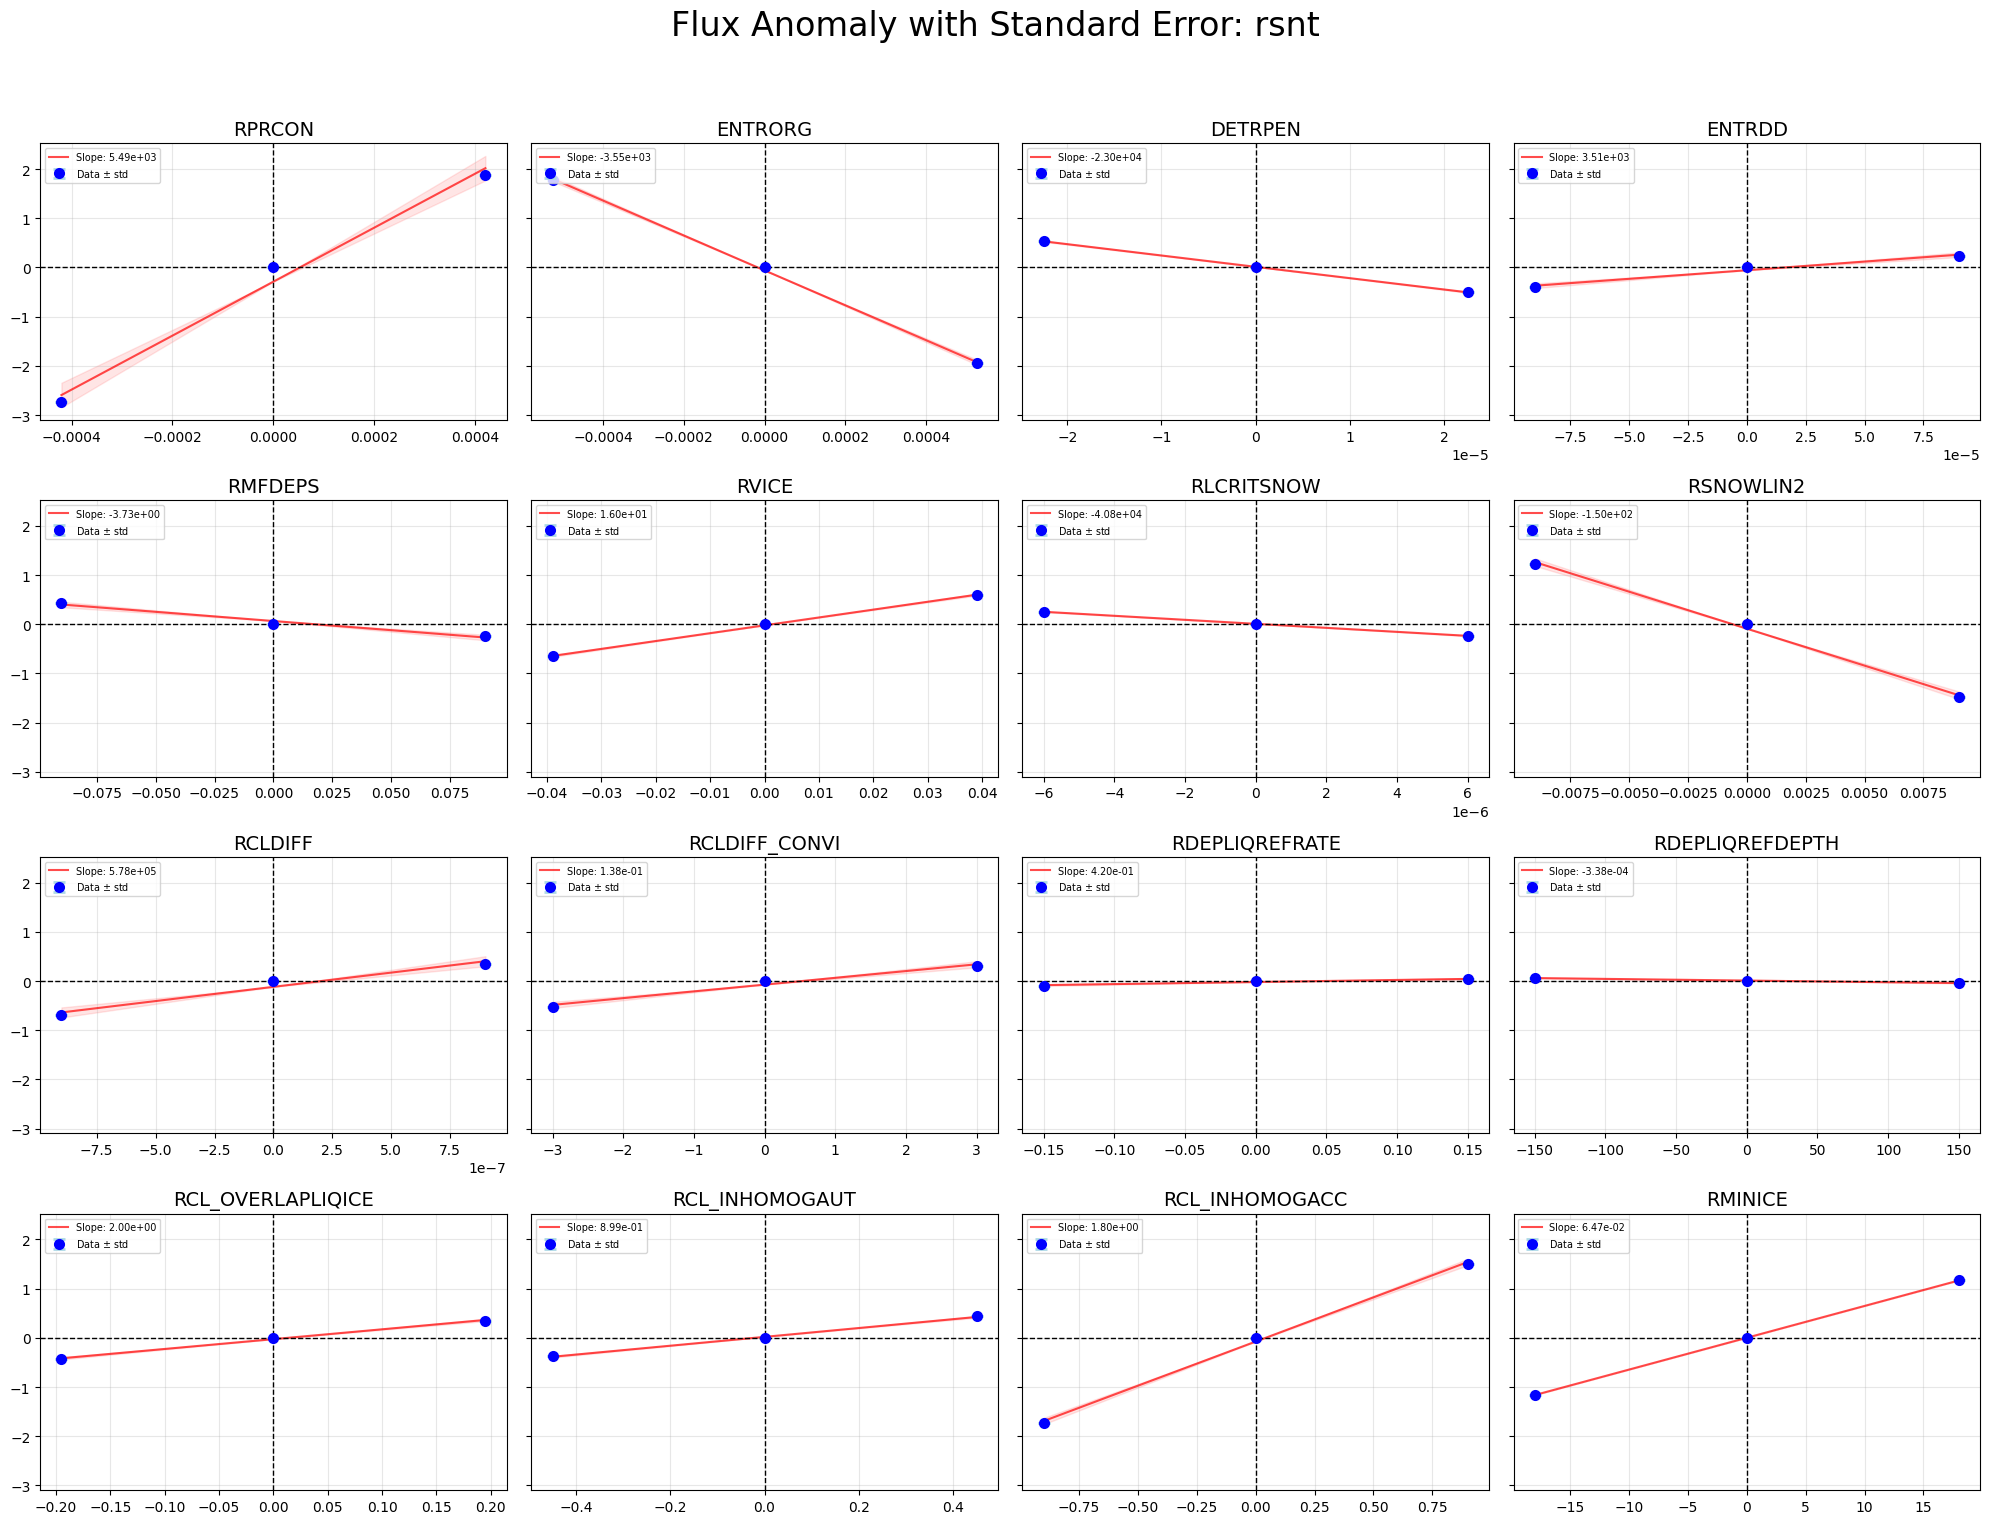

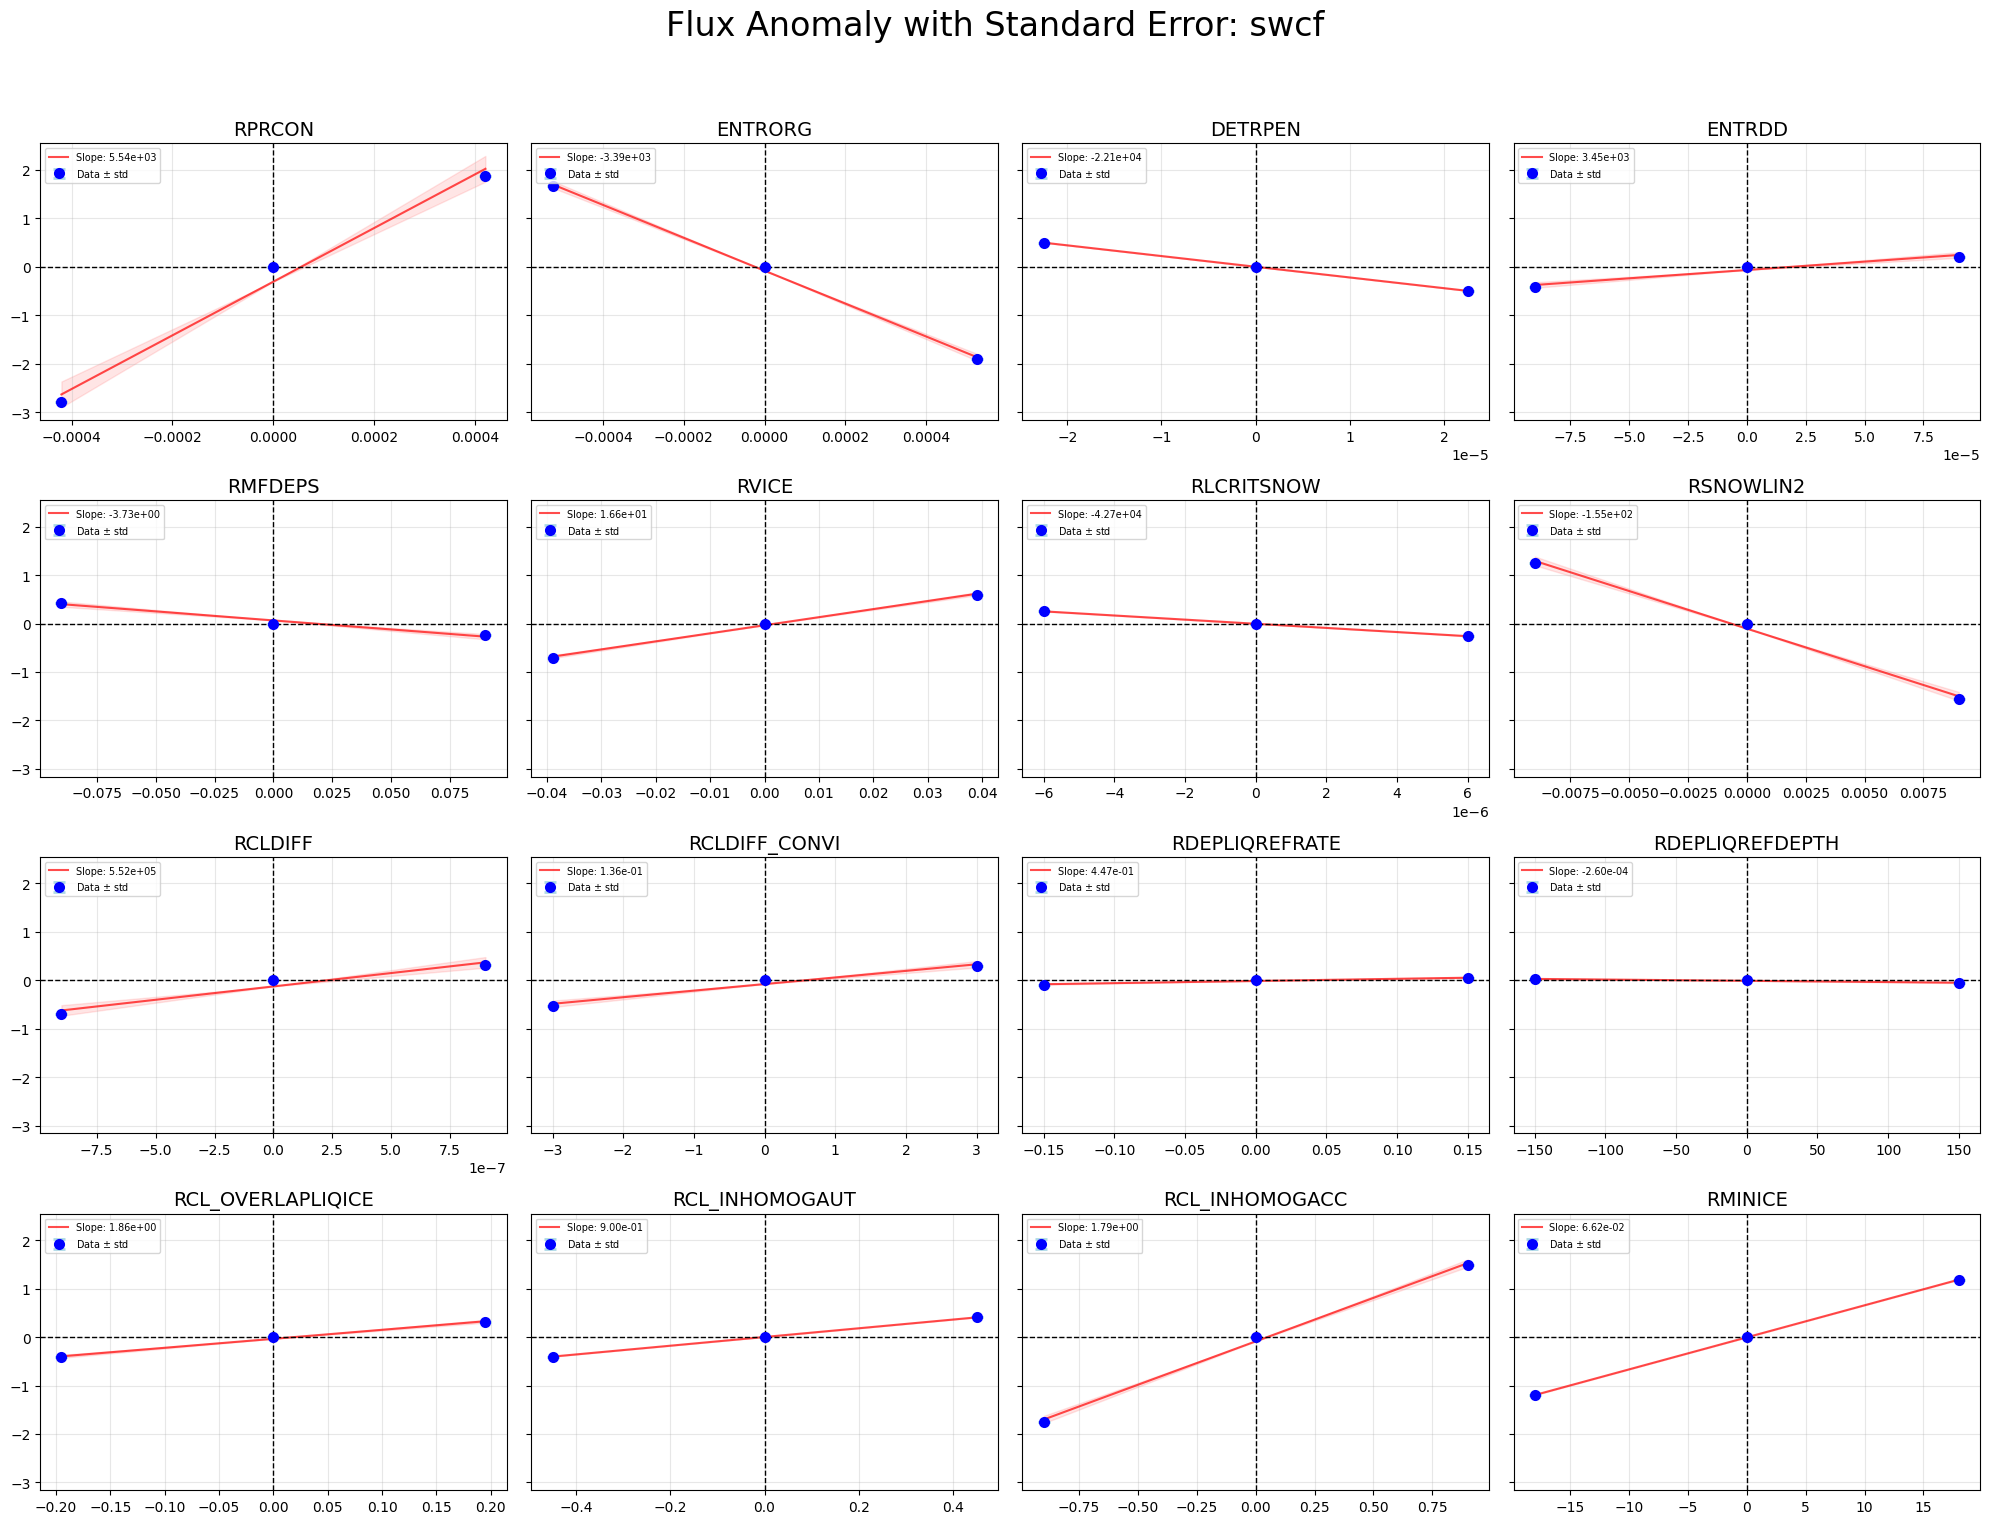

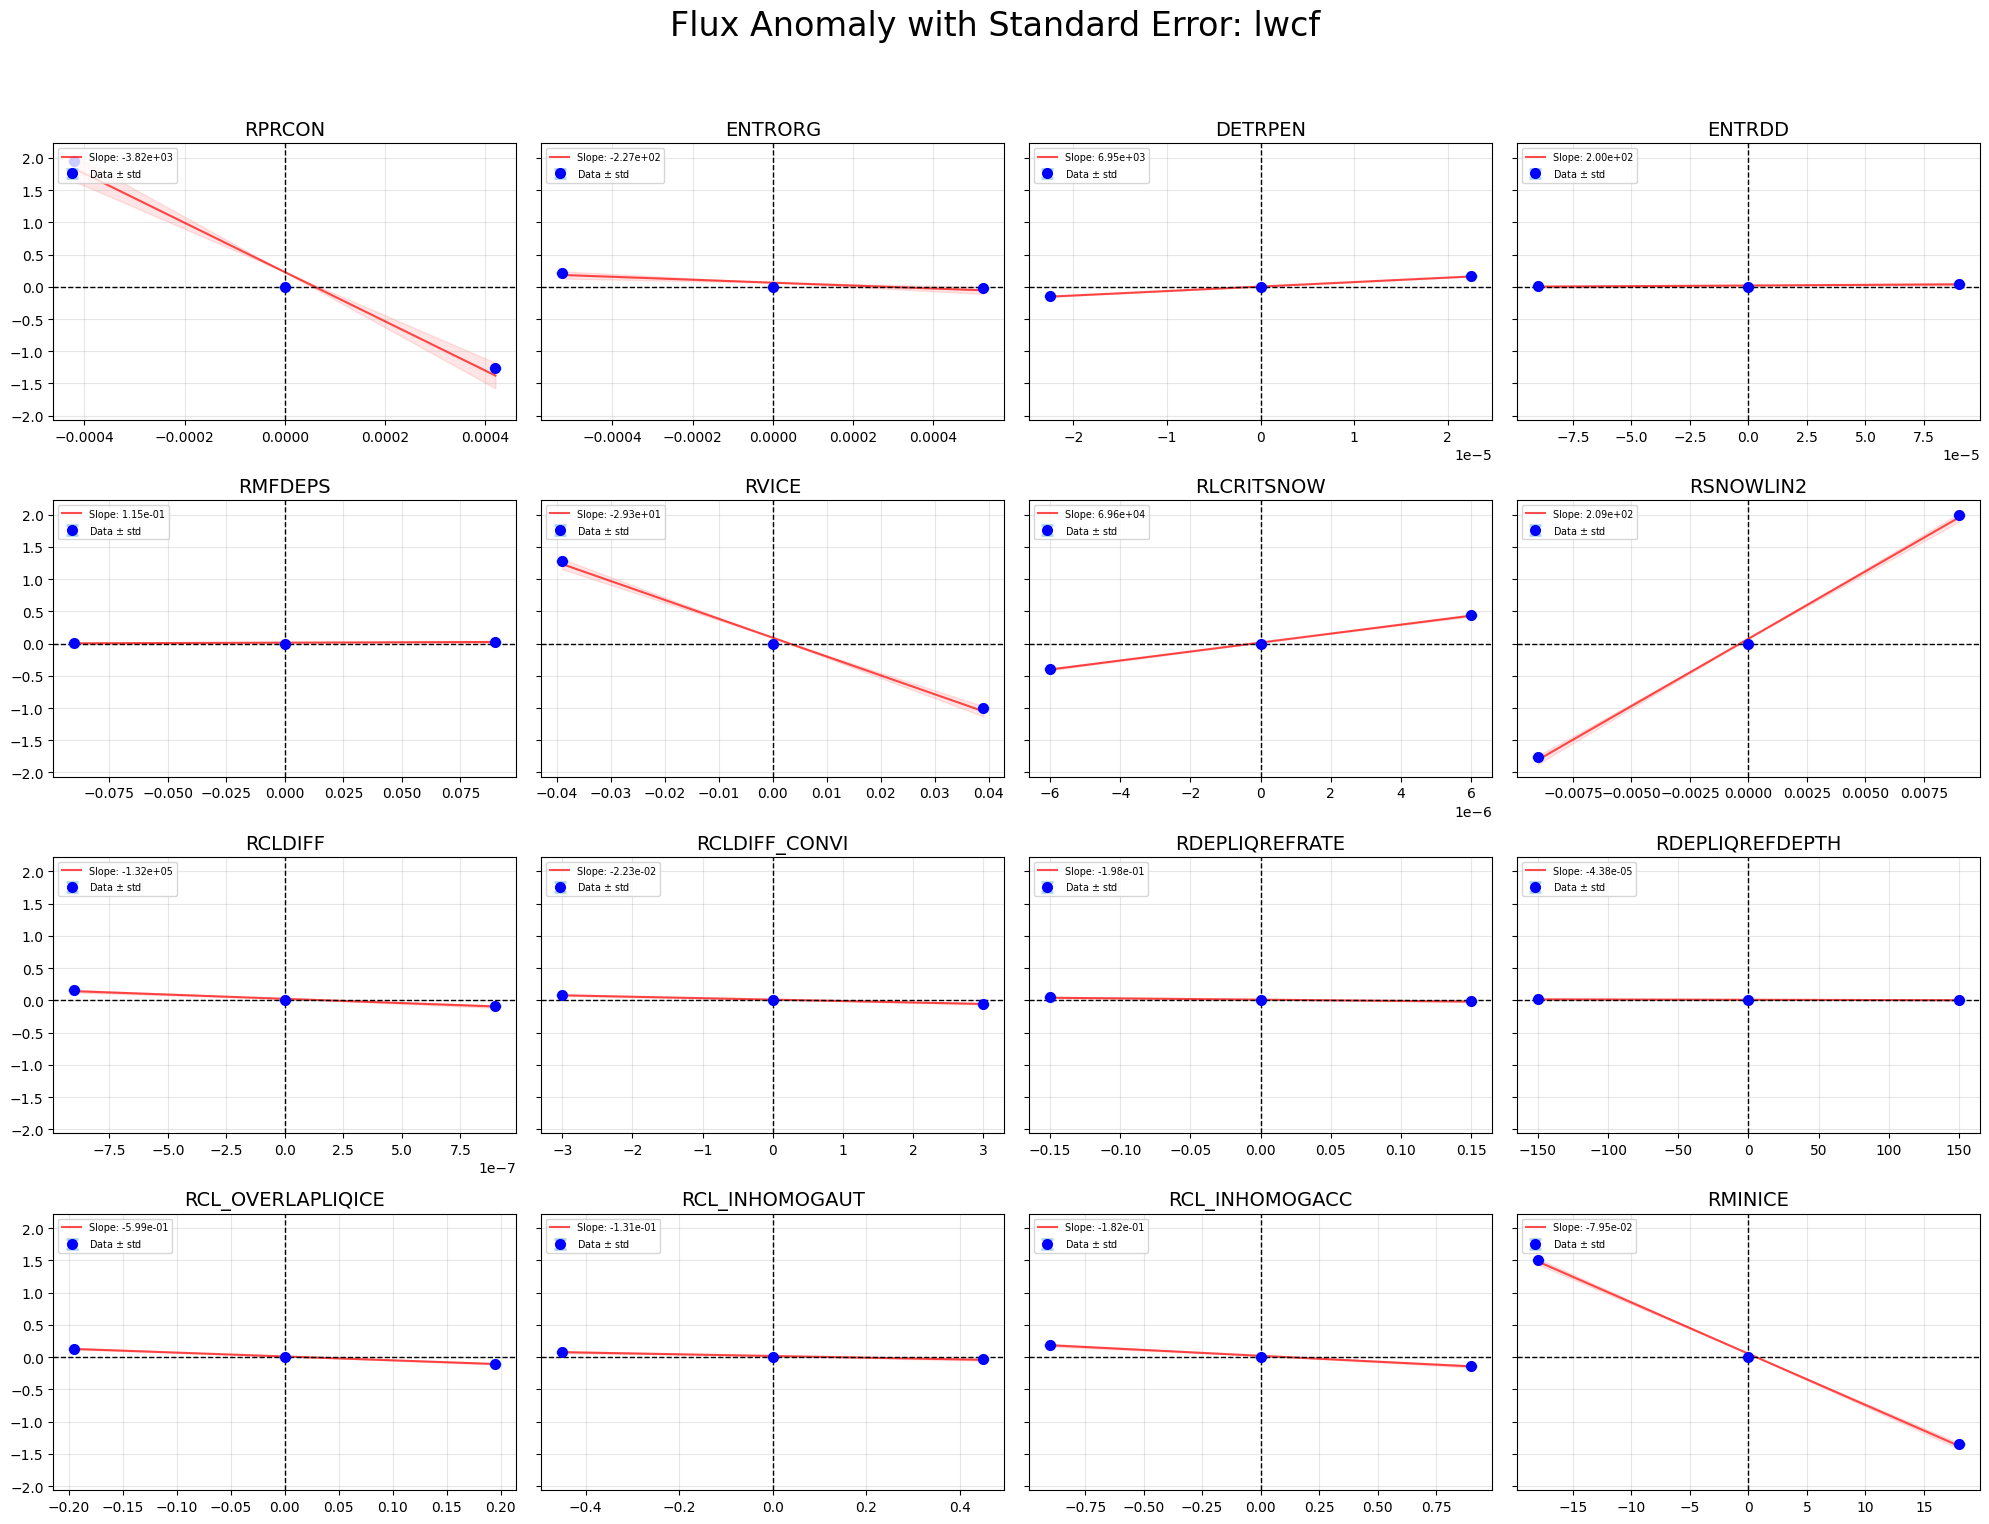

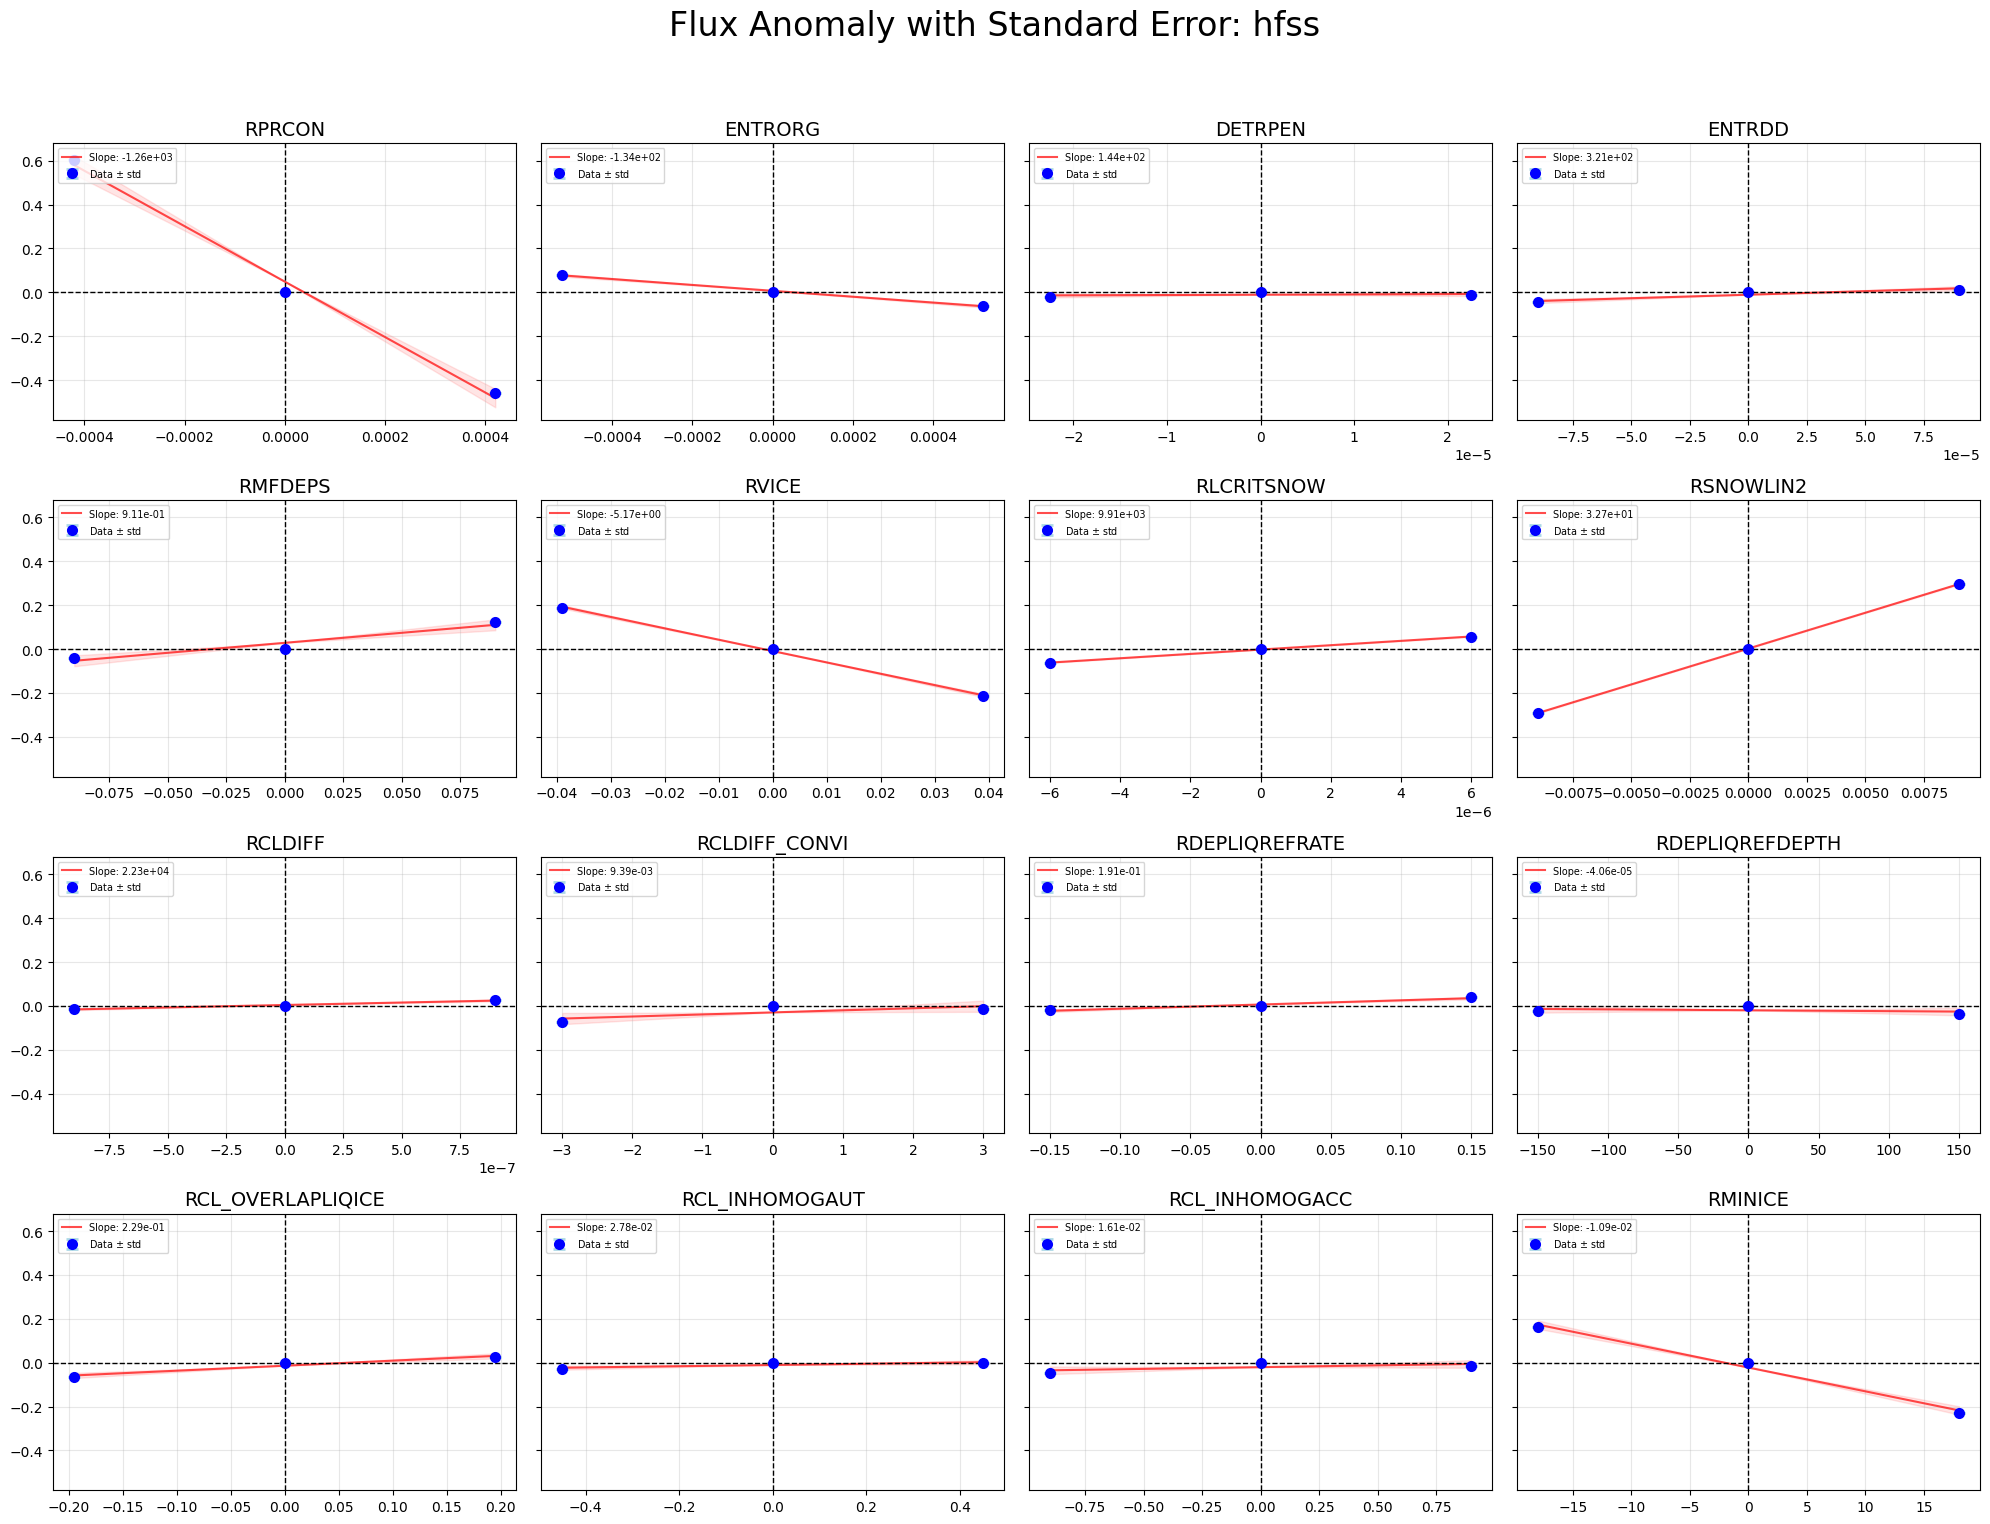

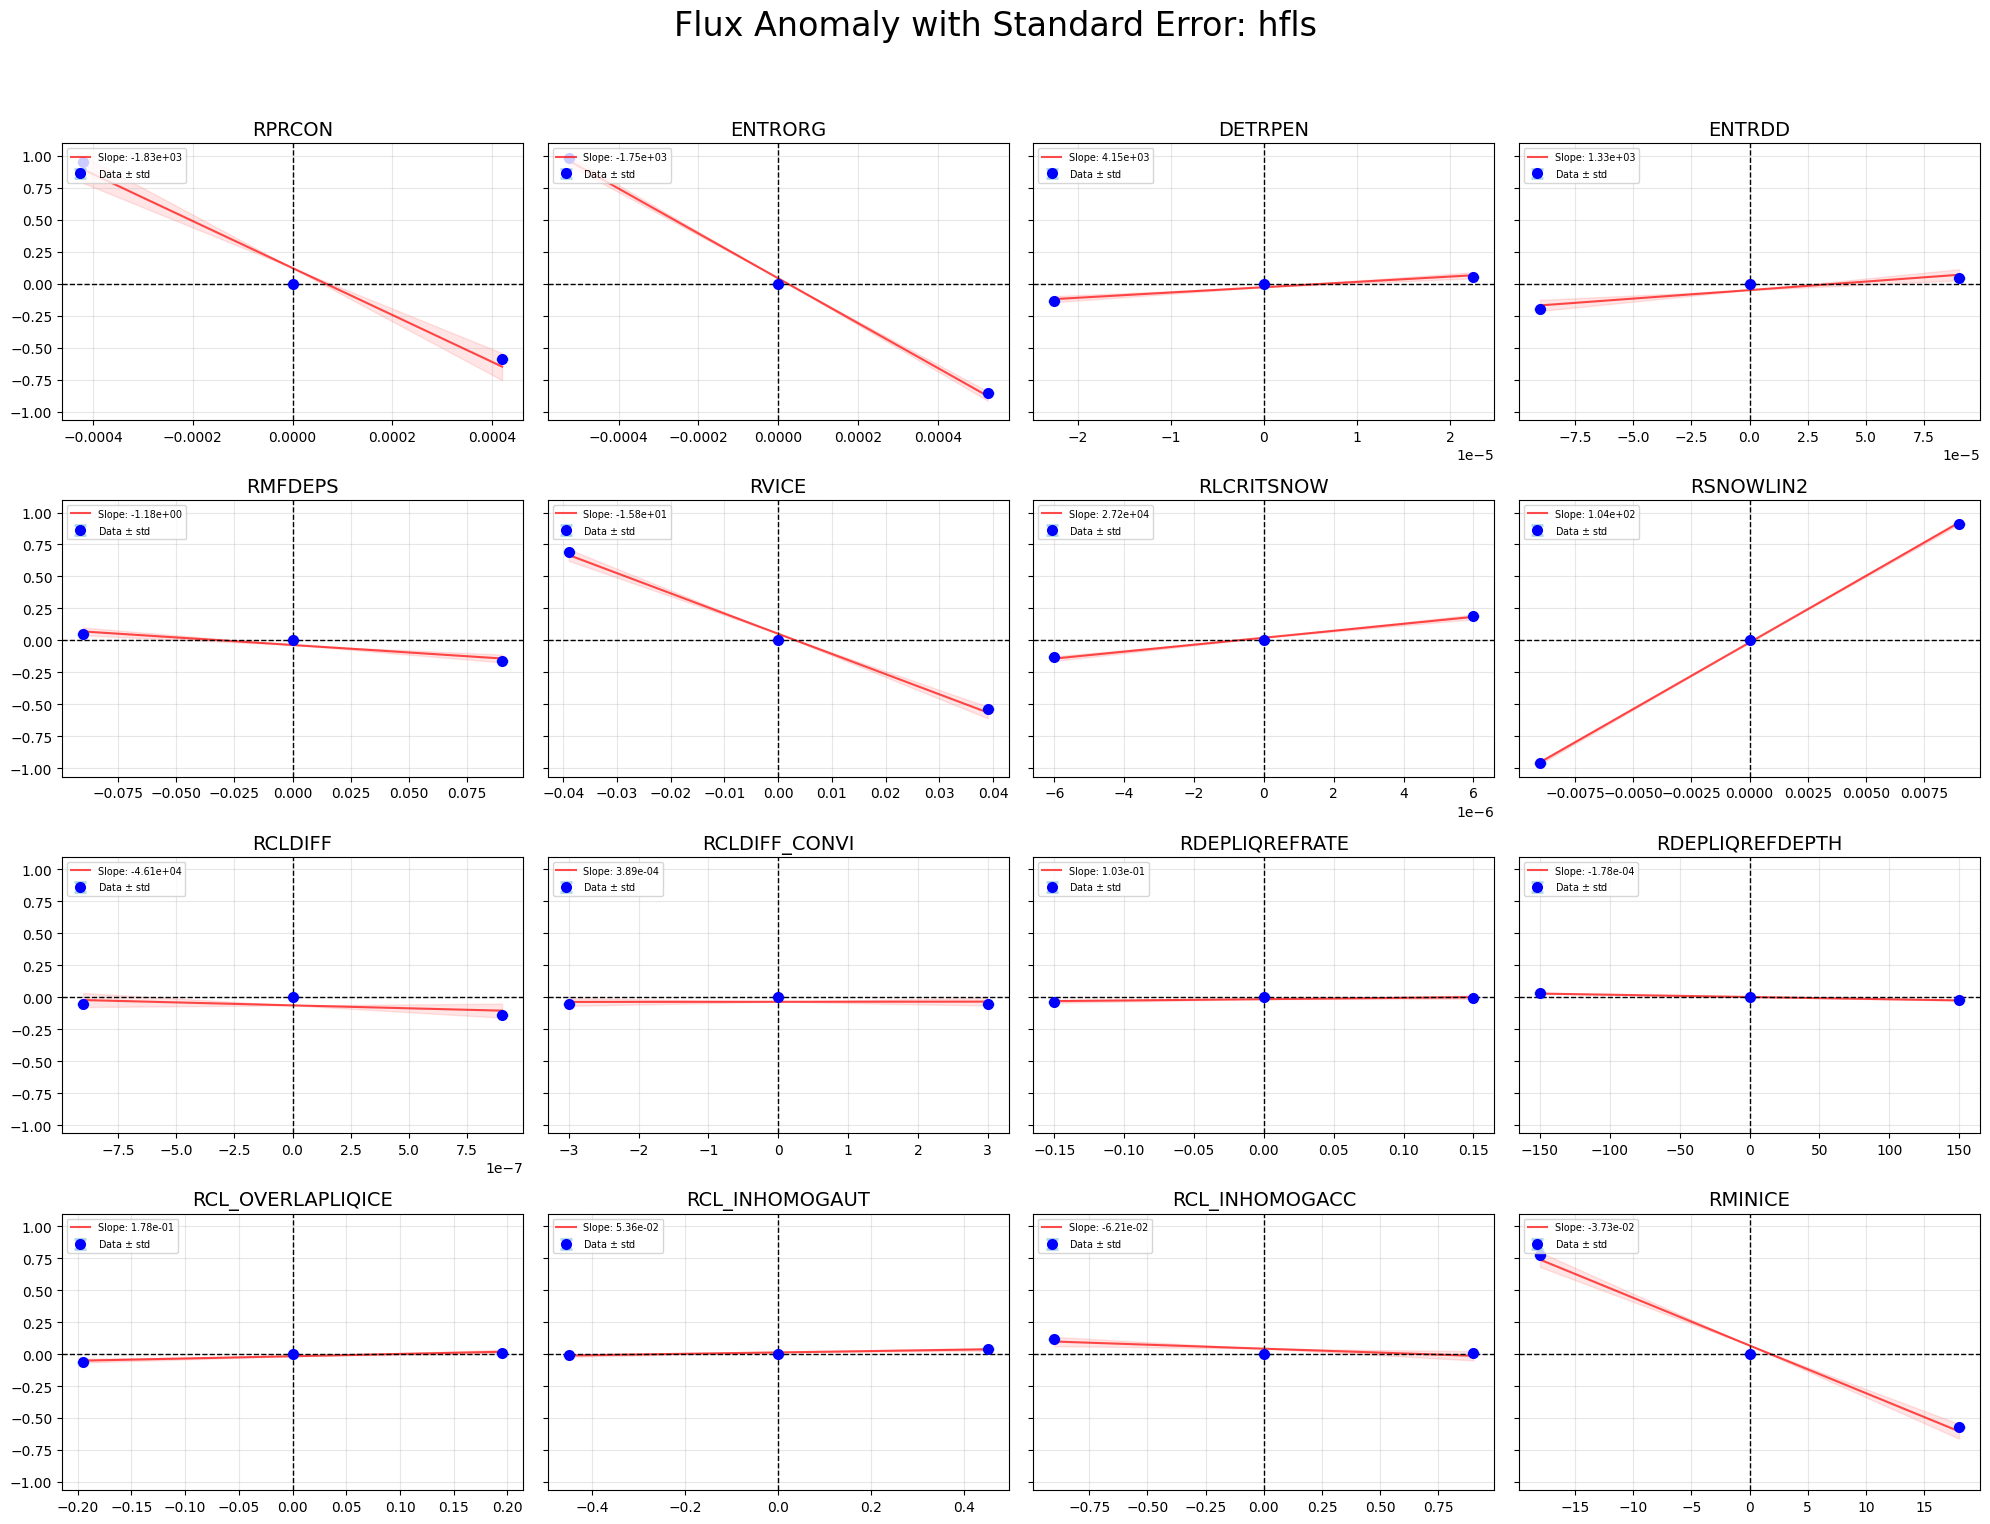

In [4]:
import os
import yaml
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# --- CONFIGURAZIONE ---
ecmean_dir = '/home/ecme3038/hpcperm/ecearth/ecearth4/ECtuner/ectuner/ecmean/gm_TL255_v2/'
exps_dir = '/home/ecme3038/hpcperm/ecearth/ecearth4/ECtuner/ectuner/perturb_exps/exps_TL255_v2/'
selected_fluxes = ['net_toa', 'rlnt', 'rsnt', 'swcf', 'lwcf', 'hfss', 'hfls']

parameter_names = [
    "RPRCON", "ENTRORG", "DETRPEN", "ENTRDD", "RMFDEPS", "RVICE", 
    "RLCRITSNOW", "RSNOWLIN2", "RCLDIFF", "RCLDIFF_CONVI", 
    "RDEPLIQREFRATE", "RDEPLIQREFDEPTH", "RCL_OVERLAPLIQICE", 
    "RCL_INHOMOGAUT", "RCL_INHOMOGACC", "RMINICE"
]

def extract_flux_with_err(filepath, fluxes):
    """Estrae valore globale e deviazione standard dai file YAML di ecmean."""
    if not os.path.exists(filepath):
        return {f: np.nan for f in fluxes}, {f: 0 for f in fluxes}
    with open(filepath, 'r') as stream:
        content = yaml.safe_load(stream)
    
    vals, errs = {}, {}
    for f in fluxes:
        data = content.get(f, {}).get('ALL', {})
        vals[f] = data.get('Global', np.nan)
        # Nota: assumiamo che il file YAML contenga 'Global_std'. 
        # Se ecmean non lo fornisce, lo standard error non può essere visualizzato.
        errs[f] = data.get('Global_std', 0) 
    return vals, errs

def extract_param(filepath, param):
    """Estrae il valore del parametro dai file tuning_XX.yml."""
    if not os.path.exists(filepath): return np.nan
    with open(filepath, 'r') as stream:
        content = yaml.safe_load(stream)
        tuning = content[0].get('base.context', {}).get('model_config', {}).get('oifs', {}).get('tuning', {})
        for group in ['namcumf', 'namcldp', 'naerad']:
            if param in tuning.get(group, {}):
                return float(tuning[group][param])
    return np.nan

# 1. Caricamento Baseline (k000)
ref_exp = 'k000'
ref_path = os.path.join(ecmean_dir, f'global_mean_{ref_exp}_EC-Earth4_r1i1p1f1_1991_2000.yml')
ref_vals, ref_errs = extract_flux_with_err(ref_path, selected_fluxes)

# 2. Elaborazione Dati
data_dict = {f: {p: {'dx': [], 'dy': [], 'yerr': []} for p in parameter_names} for f in selected_fluxes}

for idx, param in enumerate(parameter_names):
    p_ref = extract_param(os.path.join(exps_dir, 'tuning_00.yml'), param)
    
    # k000 come punto (0,0) e i due esperimenti perturbati
    for suffix in [0, 2*idx+1, 2*idx+2]:
        exp = f'k{suffix:03d}'
        f_path = os.path.join(ecmean_dir, f'global_mean_{exp}_EC-Earth4_r1i1p1f1_1991_2000.yml')
        curr_vals, curr_errs = extract_flux_with_err(f_path, selected_fluxes)
        
        p_path = os.path.join(exps_dir, f'tuning_{suffix:02d}.yml')
        p_val = extract_param(p_path, param)
        
        for f in selected_fluxes:
            if not np.isnan(curr_vals[f]) and not np.isnan(ref_vals[f]):
                # Calcolo anomalie rispetto a k000
                data_dict[f][param]['dy'].append(curr_vals[f] - ref_vals[f])
                data_dict[f][param]['dx'].append(p_val - p_ref)
                # Errore combinato (propagazione dell'errore: sqrt(err1^2 + err2^2))
                combined_err = np.sqrt(curr_errs[f]**2 + ref_errs[f]**2)
                data_dict[f][param]['yerr'].append(combined_err)

# 3. Plotting
for flux in selected_fluxes:
    cols = 4
    rows = int(np.ceil(len(parameter_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows), sharey=True)
    axes = axes.flatten()
    
    for i, param in enumerate(parameter_names):
        ax = axes[i]
        x = np.array(data_dict[flux][param]['dx'])
        y = np.array(data_dict[flux][param]['dy'])
        err = np.array(data_dict[flux][param]['yerr'])
        
        # Plot con barre d'errore verticali sui punti
        ax.errorbar(x, y, yerr=err, fmt='o', color='blue', ecolor='lightblue', 
                    capsize=4, elinewidth=2, markeredgewidth=2, label='Data $\pm$ std')
        
        if len(x) >= 2:
            # Regressione lineare
            slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
            x_range = np.linspace(min(x), max(x), 100)
            ax.plot(x_range, slope*x_range + intercept, color='red', alpha=0.7, 
                    label=f'Slope: {slope:.2e}')
            
            # Area di confidenza della pendenza (opzionale, come nel PDF)
            ax.fill_between(x_range, (slope-std_err)*x_range + intercept, 
                             (slope+std_err)*x_range + intercept, color='red', alpha=0.1)
        
        ax.axhline(0, color='black', lw=1, ls='--')
        ax.axvline(0, color='black', lw=1, ls='--')
        ax.set_title(param, fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize='x-small', loc='upper left')

    plt.suptitle(f'Flux Anomaly with Standard Error: {flux}', fontsize=24, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(f'/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/plots/sensitivities/TL255v2_errorbars_{flux}.png')